# **Function 3 - Bayesian Optimisation**

# Function 3 Description

You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.

Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.

Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).

# Starting point

* Input - 3D array (15,3)
* Output - 1D array (15,)
* Optimisation goal - Maximise

# Bayesian Optimisation (BO) workflow on capstone project
BO with Upper Control Bound (UCB)
Visuals of progress and surrogate intuition
Final training with the optimized hyperparameters

*  BO with Upper Control Bound (UCB)
*  Visuals of progress and surrogate intuition
*  Final training with the optimized hyperparameters

### Import Libraries

In [2]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [3]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [4]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs3.npy')
    y_array = np.load('/content/data/initial_outputs3.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs3.npy')
        y_array = np.load('data/initial_outputs3.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(15, 3) # 15 samples, 3 features
       y_array = np.random.rand(15,)  # 15 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (15, 3)
Shape of y (NumPy array): (15,)

First 5 rows of X (DataFrame):


,0,1,2
0,0.171525,0.343917,0.248737
1,0.242114,0.644074,0.272433
2,0.534906,0.398501,0.173389
3,0.492581,0.611593,0.340176
4,0.134622,0.219917,0.458206



First 5 rows of y (DataFrame):


,target_output
0,-0.112122
1,-0.087963
2,-0.111415
3,-0.034835
4,-0.048008


To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [5]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 2 features per data point
# Let's add 3 new data points
new_X_points = np.array([
    [0.100000, 0.500000, 0.999999], # week 1 capstone submission - eye ball new point 0, index 15
    [0.470879, 0.091424, 0.526144], # week 2 capstone submission - UCB KAPPA=30.0 exploration new point 1, index 16
    [0.470879, 0.091424, 0.526144], # week 3 capstone submission - UCB KAPPA=30.0 exploration, new point 2, index 17
    [0.982238, 0.837434, 0.557860], # week 4 capstone submission - UCB KAPPA=5.0 exploitation, new point 3, index 18
    [0.770346, 0.265067, 0.413198], # week 5 capstone submission - UCB KAPPA=5.0 exploitation, new point 4, index 19
    [0.576912, 0.021265, 0.461153], # week 6 capstone submission - UCB KAPPA=100.0 exploration, new point 5 index 20
    [0.787266, 0.954429, 0.544147], # week 7 capstone submission - UCB KAPPA=500.0 exploration, new point 6, index 21
    [0.771158, 0.512473, 0.056730], # week 8 capstone submission - UCB KAPPA=500.0 exploration, new point 7, index 22
    [0.356080, 0.725086, 0.144166], # week 9 capstonse submission, using a KAPPA of 1000, new point 8, index 23 from BO
    [0.856061, 0.595525, 0.873412], # week 10 capstonse submission, using a KAPPA of 1.0, new point 9, index 24 from BO changed N_INIT to 10 and N_ITER to 20
    [0.349180, 0.804252, 0.963565], # week 11 capstone submission, using a KAPPA of 0.10
    [0.490695, 0.780011, 0.414104], # week 12 capstone submission using a KAPPA of 0.10 and added min_samples_leaf to search space
  # [0.983293, 0.780180, 0.999332]  # Weeek 13 KAPPA set to 0.10 and increased learning rate range from 0.30 and 0.50
])

# For y (target), assume a single output value per data point
new_y_points = np.array([
    -0.4427870781150444,   # week 1 capstone processed output
    -0.09532708478311677,  # week 2 capstone processed output
    -0.10598253367694807,  # week 3 capstone processed output
    -0.046333913636811136, # week 4 capstone processed output
    -0.02960535044392163,  # week 5 capstone processed output
    -0.09215147798763072,  # week 6 capstone processed output
    -0.042959853656009434, # week 7 capstone processed output
    -0.04049299000819705,  # week 8 capstone processed output
    -0.09782919526958835,  # week 9 capstone processed output
    -0.036982567065521124, # week 10 capstone processed output
    -0.2825658074719054,   # week 11 capstone processed output
     -0.021870019458936085 # week 12 capstone processed output
     # week 13 capstone processed output
])

# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (15, 3)
Original y shape: (15,)
New X points shape: (12, 3)
New y points shape: (12,)

Updated X shape: (27, 3)
Updated y shape: (27,)

Last 5 rows of updated X:


,0,1,2
22,0.771158,0.512473,0.056730
23,0.356080,0.725086,0.144166
24,0.856061,0.595525,0.873412
25,0.349180,0.804252,0.963565
26,0.490695,0.780011,0.414104



Last 5 rows of updated y:


,target_output
22,-0.040493
23,-0.097829
24,-0.036983
25,-0.282566
26,-0.021870


### **Week 12 KAPPA set to 0.10 from BO, added min_samples_leaf to search space**

 - Suggested next X data point (3D coordinates): [0.49069489 0.78001068 0.41410396]
 - Predicted Y at this point (mean): -9.99342e-02
 - Predicted uncertainty (std) at this point: 1.03232e-01
 - UCB value at this point: 4.16224e-01


### **Week 12 KAPPA set to 0.10 from BO, added min_samples_leaf to search space**

 - Suggested next X data point (3D coordinates): [0.49069489 0.78001068 0.41410396]
 - Predicted Y at this point (mean): -9.99342e-02
 - Predicted uncertainty (std) at this point: 1.03232e-01
 - UCB value at this point: 4.16224e-01


Minimum y value: -4.4278707812e-01
Maximum y value: -2.1870019459e-02


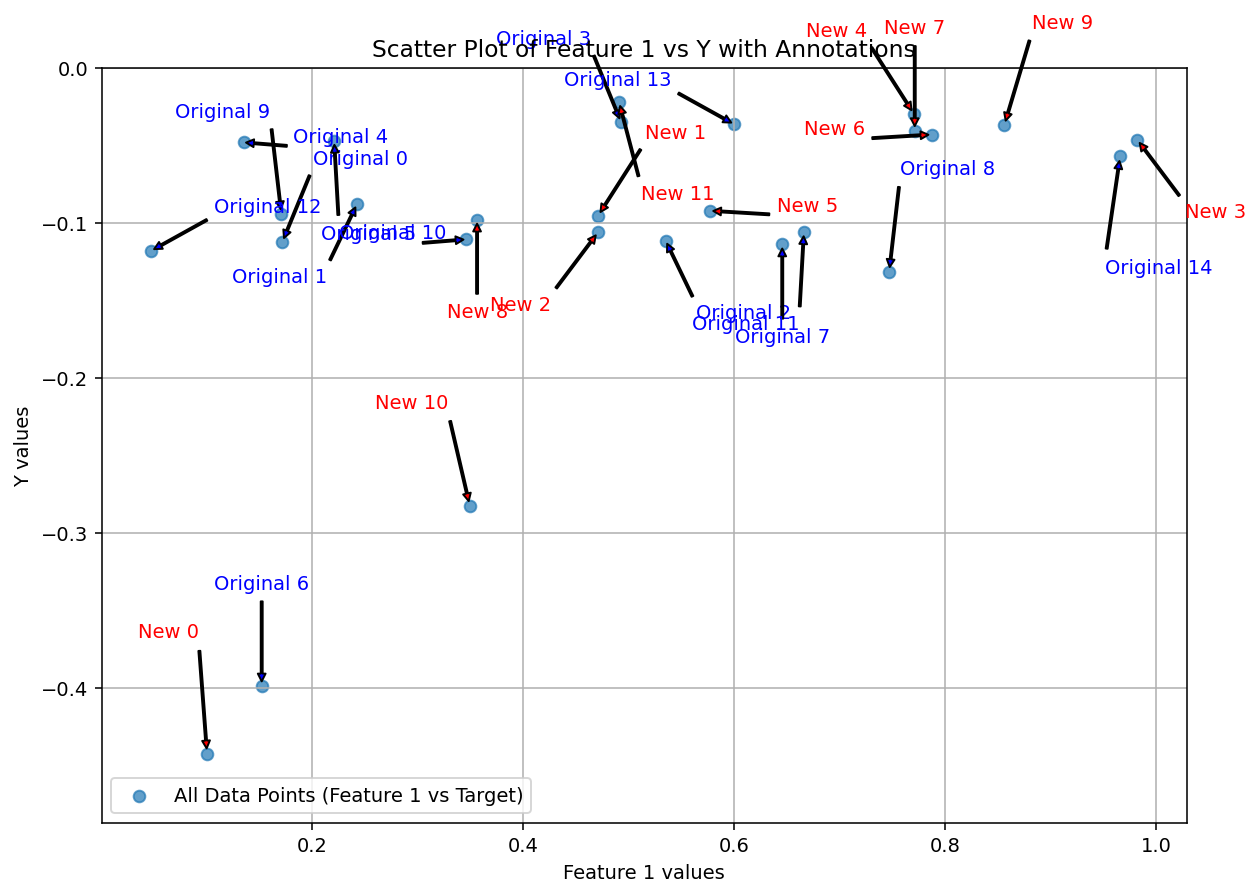

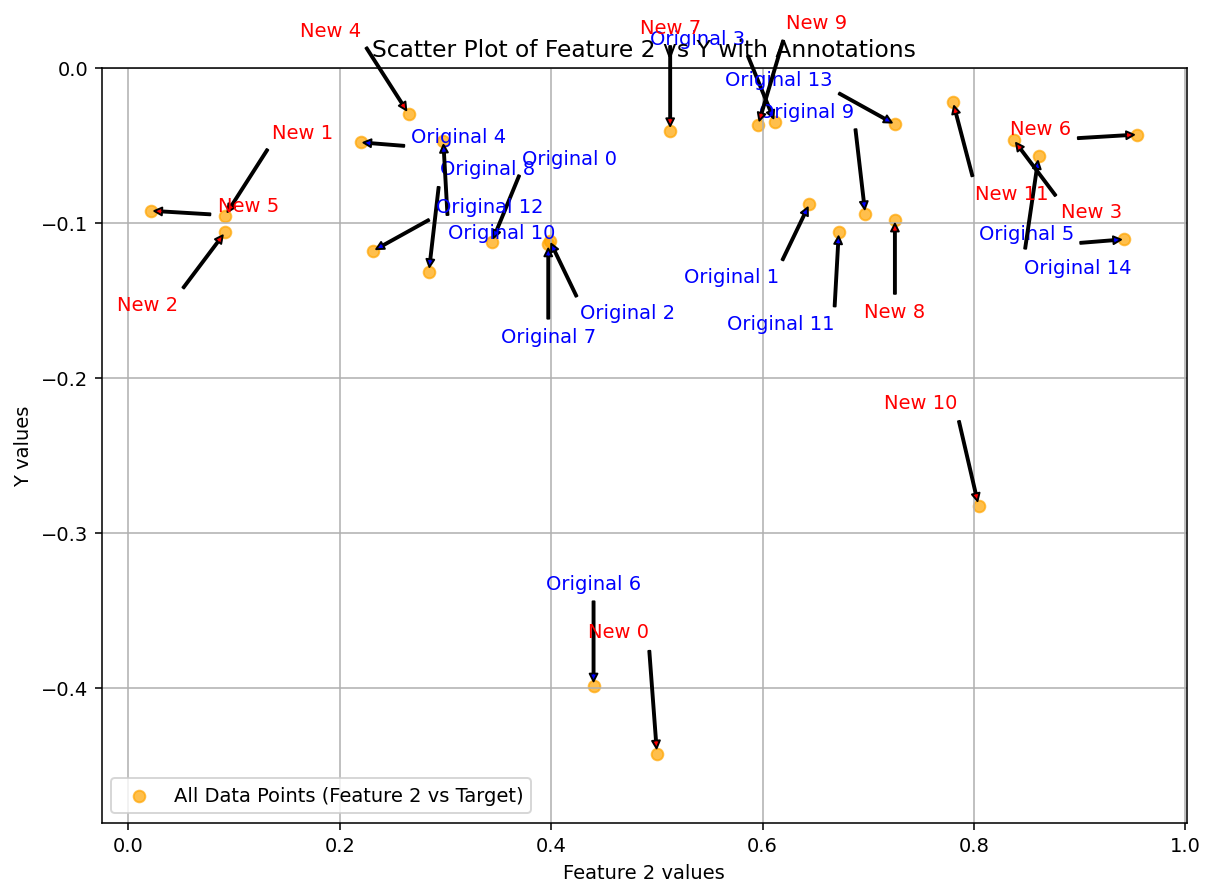

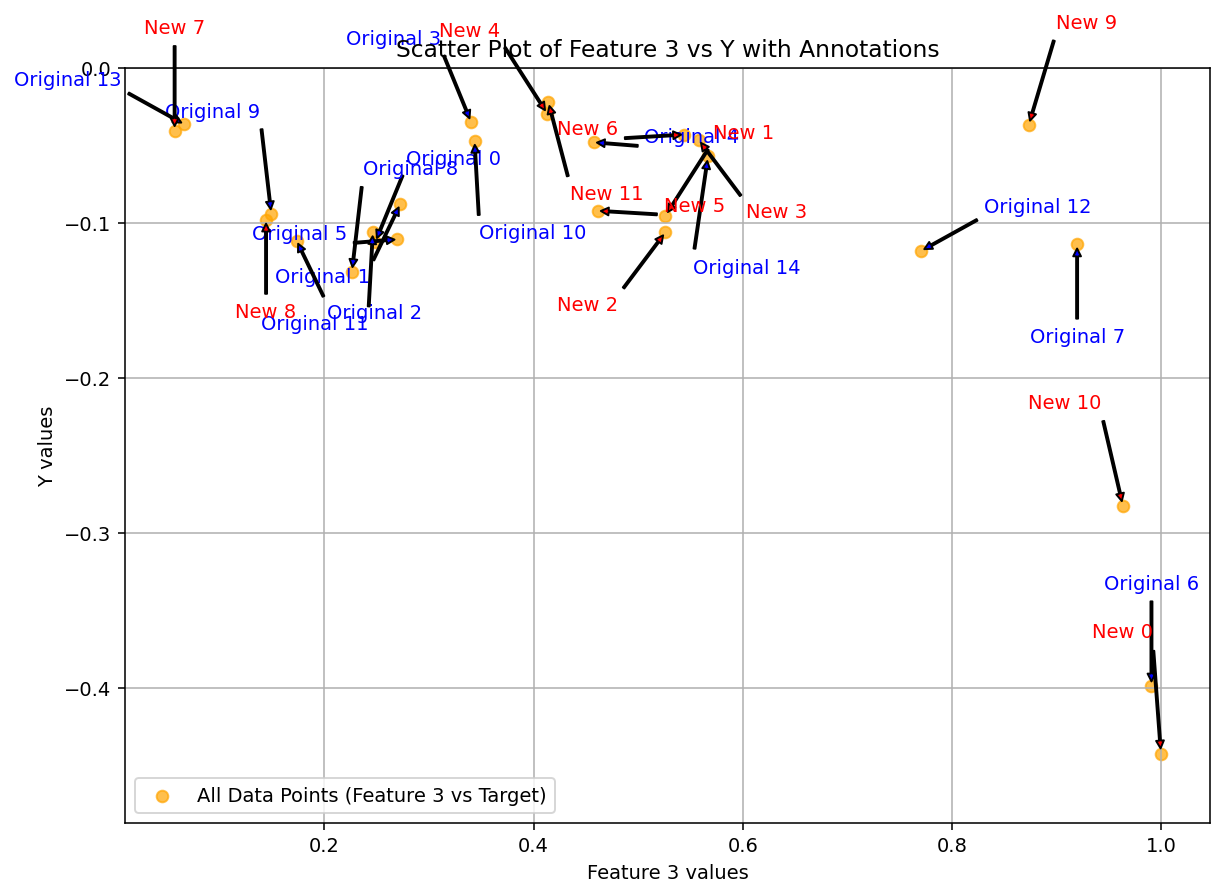

In [7]:
print(f"Minimum y value: {np.min(y):.10e}")
print(f"Maximum y value: {np.max(y):.10e}")

plt.figure(figsize=(10, 7)) # Increased figure size for better readability
plt.scatter(X[:, 0], y, label='All Data Points (Feature 1 vs Target)', alpha=0.7)
plt.xlabel('Feature 1 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 1 vs Y with Annotations')
plt.legend()
plt.grid(True)

# Set y-axis limits to clearly show negative values
y_min = np.min(y)
y_max = np.max(y)
plt.ylim(y_min - abs(y_min * 0.1), y_max + abs(y_max * 0.1) if y_max > 0 else 1e-8) # Add a small buffer

# Define a list of larger offsets to cycle through for better annotation placement
offsets = [
    (40, 40), (-40, -40), (40, -40), (-40, 40),
    (50, 0), (-50, 0), (0, 50), (0, -50),
    (30, 50), (-30, 50), (30, -50), (-30, -50),
    (60, 20), (-60, 20), (20, -60), (-20, 60)
]

# Annotate each point for Feature 1
num_original_points = X_array.shape[0]
for i in range(X.shape[0]):
    offset = offsets[i % len(offsets)] # Cycle through offsets
    if i < num_original_points:
        label = f'Original {i}'
        color = 'blue'
    else:
        label = f'New {i - num_original_points}'
        color = 'red' # Use a different color for new points to distinguish visually
    plt.annotate(
        label,
        (X[i, 0], y[i]),
        textcoords="offset points",
        xytext=offset,
        ha='center',
        color=color,
        arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=4, headlength=4)
    )
plt.show()

plt.figure(figsize=(10, 7)) # Increased figure size for better readability
plt.scatter(X[:, 1], y, label='All Data Points (Feature 2 vs Target)', color='orange', alpha=0.7)
plt.xlabel('Feature 2 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 2 vs Y with Annotations')
plt.legend()
plt.grid(True)

# Set y-axis limits for the second plot as well
plt.ylim(y_min - abs(y_min * 0.1), y_max + abs(y_max * 0.1) if y_max > 0 else 1e-8) # Add a small buffer

# Annotate each point for Feature 2
for i in range(X.shape[0]):
    offset = offsets[i % len(offsets)] # Cycle through offsets
    if i < num_original_points:
        label = f'Original {i}'
        color = 'blue'
    else:
        label = f'New {i - num_original_points}'
        color = 'red' # Use a different color for new points to distinguish visually
    plt.annotate(
        label,
        (X[i, 1], y[i]),
        textcoords="offset points",
        xytext=offset,
        ha='center',
        color=color,
        arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=4, headlength=4)
    )
plt.show()

plt.figure(figsize=(10, 7)) # Increased figure size for better readability
plt.scatter(X[:, 2], y, label='All Data Points (Feature 3 vs Target)', color='orange', alpha=0.7)
plt.xlabel('Feature 3 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 3 vs Y with Annotations')
plt.legend()
plt.grid(True)

# Set y-axis limits for the third plot as well
plt.ylim(y_min - abs(y_min * 0.1), y_max + abs(y_max * 0.1) if y_max > 0 else 1e-8) # Add a small buffer

# Annotate each point for Feature 3
for i in range(X.shape[0]):
    offset = offsets[i % len(offsets)] # Cycle through offsets
    if i < num_original_points:
        label = f'Original {i}'
        color = 'blue'
    else:
        label = f'New {i - num_original_points}'
        color = 'red' # Use a different color for new points to distinguish visually
    plt.annotate(
        label,
        (X[i, 2], y[i]), # Corrected from X[i, 1] to X[i, 2]
        textcoords="offset points",
        xytext=offset,
        ha='center',
        color=color,
        arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=4, headlength=4)
    )
plt.show()


# The problem states that the goal is to minimise side effects, but it's framed as maximisation by optimising a transformed output (e.g., the negative of side effects).

# This means:

If y represents the negative of side effects, then higher y values are better.

Since all the y values we're observing are negative, a y value that is closest to zero (e.g., -0.0296) is indeed the highest (least negative) value, and thus represents the lowest side effects.

Therefore, the Bayesian Optimisation is correctly trying to find the X points that yield y values closest to zero. The 'Top 3 Highest Output Values (y)' that are printed below are precisely those values that are closest to zero, indicating the best performing combinations of compounds found so far to minimise side effects.

In [8]:
print("Finding the top 3 input (X) values that generated the highest output (y) values:")

# Get indices that would sort y in descending order (highest values are at the beginning)
sorted_indices_highest = np.argsort(y)[::-1]

# Select the top 3 indices for the highest y values
top_3_indices_highest = sorted_indices_highest[:3]

# Get the corresponding X and y values
top_3_X_highest = X[top_3_indices_highest]
top_3_y_highest = y[top_3_indices_highest]

print("\nTop 3 Highest Output Values (y) and their corresponding X values which are closest to Zero:")
for i, val_y in enumerate(top_3_y_highest):
  print(f"   Original Index: {top_3_indices_highest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_highest[i]}")
  print("\n")

print("Finding the top 3 input (X) values that generated the lowest output (y) values:")

# Get indices that would sort y in ascending order (lowest values are at the beginning)
sorted_indices_lowest = np.argsort(y)

# Select the top 3 indices for the lowest y values
top_3_indices_lowest = sorted_indices_lowest[:3]

# Get the corresponding X and y values
top_3_X_lowest = X[top_3_indices_lowest]
top_3_y_lowest = y[top_3_indices_lowest]

print("\nTop 3 Lowest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_lowest):
  print(f"   Original Index: {top_3_indices_lowest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_lowest[i]}")
  print("\n")

Finding the top 3 input (X) values that generated the highest output (y) values:

Top 3 Highest Output Values (y) and their corresponding X values which are closest to Zero:
   Original Index: 26
   y value: -2.1870019459e-02
   Corresponding X values: [0.490695 0.780011 0.414104]


   Original Index: 19
   y value: -2.9605350444e-02
   Corresponding X values: [0.770346 0.265067 0.413198]


   Original Index: 3
   y value: -3.4835313350e-02
   Corresponding X values: [0.49258141 0.61159319 0.34017639]


Finding the top 3 input (X) values that generated the lowest output (y) values:

Top 3 Lowest Output Values (y) and their corresponding X values:
   Original Index: 15
   y value: -4.4278707812e-01
   Corresponding X values: [0.1      0.5      0.999999]


   Original Index: 6
   y value: -3.9892551315e-01
   Corresponding X values: [0.15183663 0.43999062 0.99088187]


   Original Index: 25
   y value: -2.8256580747e-01
   Corresponding X values: [0.34918  0.804252 0.963565]




### Objective and baseline
Baseline model provides us the RMSE benchmark as a starting point

In [9]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

baseline = GradientBoostingRegressor(random_state=42)
baseline_rmse = rmse_cv(baseline)
print(f"Baseline GBR RMSE (5-fold): {baseline_rmse:.3f}")

Baseline GBR RMSE (5-fold): 0.048


### Search Space and Helper Functions

In [27]:
# Search space for 3D input
space = {
    "n_estimators": (50, 600), #increased from 300 to 600 in week 10
    "learning_rate": (0.01, 0.50), # increased from 0.30 to 0.50 in week 13
    "max_depth": (1, 10),  # Added max_depth to search space (integer)
    "subsample": (0.5, 1.0), # Added subsample to search space (float) # added hyperparameter into search space for Week 9
    "min_samples_leaf": (1, 20) # Added min_samples_leaf to search space (integer)
}
hp = list(space.keys()); d = len(hp) # d will now be 4

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers like n_estimators or max_depth)
def to_params(x01):
    out = {}
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name == "n_estimators" or name == "max_depth" or name == "min_samples_leaf": # n_estimators, max_depth, and min_samples_leaf are integers
            v = int(round(v))
        out[name] = float(v)
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV RMSE. So BO minimizes error (RMSE)
def objective(params):
    # fixed_subsample remains fixed as it's not part of the 3D search space
    # This line is removed as subsample is now part of the optimized parameters
    # fixed_subsample = 0.8 # A reasonable default value

    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        min_samples_leaf=int(params["min_samples_leaf"]), # Added min_samples_leaf
        random_state=42
    )
    return rmse_cv(model)

# The normal_pdf and normal_cdf functions remain unchanged
def normal_pdf(z):
    if scipy_OK:
        return norm.pdf(z)
    return (1.0/np.sqrt(2*np.pi))*np.exp(-0.5*z**2)

def normal_cdf(z):
    if scipy_OK:
        return norm.cdf(z)
    return 0.5*(1+np.erf(z/np.sqrt(2)))

### Step by Step BO with UCB decomposition

#### Import Libraries

In [28]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibilityty

In [29]:
@dataclass
class StepLog:
    it: int; params: dict; rmse: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_rmse: float

In [31]:
N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 0.10, 2000 # included min_samples_leaf in search space from week 12
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 0.10, 2000 # changed N_INIT to 10 and N_ITER to 20.0 from week 10
rng = np.random.RandomState(123)

#### Warm-up trials - BO needs some initial data to train the surrogate

In [32]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials])
best_rmse = float(np.min(y_trials))

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [33]:
logs = []
cum_best = np.minimum.accumulate(y_trials)
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [34]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_rmse]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

In [35]:
for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate
    # UCB = mu + KAPPA * std. We want to maximize this.
    ucb = mu + KAPPA * std

    # Pick the candidate with maximum UCB
    idx = int(np.argmax(ucb)); x_next = CAND[idx]
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction
    contrib_explore = float(KAPPA * std[idx]) # Exploration is driven by uncertainty weighted by KAPPA
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx]) else "UCB (Exploitation)"

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next)
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next < best_rmse: best_rmse = float(y_next)
    trace.append(best_rmse)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_rmse))


#### Log final step log DataFrame

In [36]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "rmse": s.rmse, "best_rmse_so_far": s.best_rmse,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(20)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,0.094956,0.094956,NaN,NaN,NaN,NaN,NaN,433.0,0.150208,3.0,0.775657,15.0
1,-8,Warm-up,0.078766,0.078766,NaN,NaN,NaN,NaN,NaN,283.0,0.490574,7.0,0.740466,8.0
2,-7,Warm-up,0.094573,0.078766,NaN,NaN,NaN,NaN,NaN,239.0,0.367234,5.0,0.529839,9.0
3,-6,Warm-up,0.096219,0.078766,NaN,NaN,NaN,NaN,NaN,456.0,0.099421,3.0,0.765776,11.0
4,-5,Warm-up,0.096438,0.078766,NaN,NaN,NaN,NaN,NaN,399.0,0.426222,8.0,0.805512,15.0
5,-4,Warm-up,0.098726,0.078766,NaN,NaN,NaN,NaN,NaN,228.0,0.187276,3.0,0.646857,13.0
6,-3,Warm-up,0.097623,0.078766,NaN,NaN,NaN,NaN,NaN,101.0,0.222514,5.0,0.746843,9.0
7,-2,Warm-up,0.096441,0.078766,NaN,NaN,NaN,NaN,NaN,222.0,0.218912,9.0,0.972080,11.0
8,-1,Warm-up,0.096101,0.078766,NaN,NaN,NaN,NaN,NaN,393.0,0.066653,4.0,0.707413,17.0
9,0,Warm-up,0.098602,0.078766,NaN,NaN,NaN,NaN,NaN,188.0,0.246687,10.0,0.759743,13.0


### Visuals

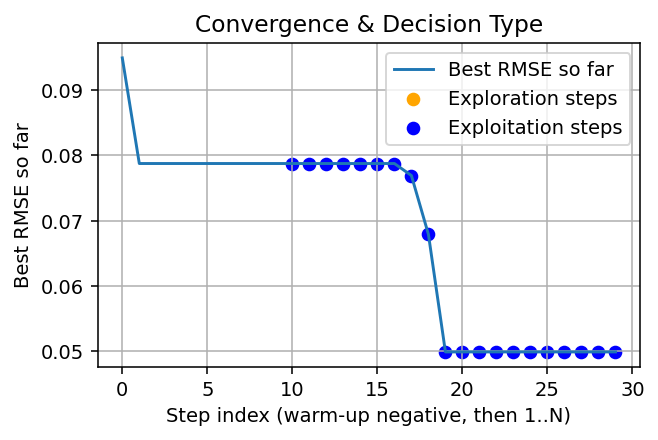

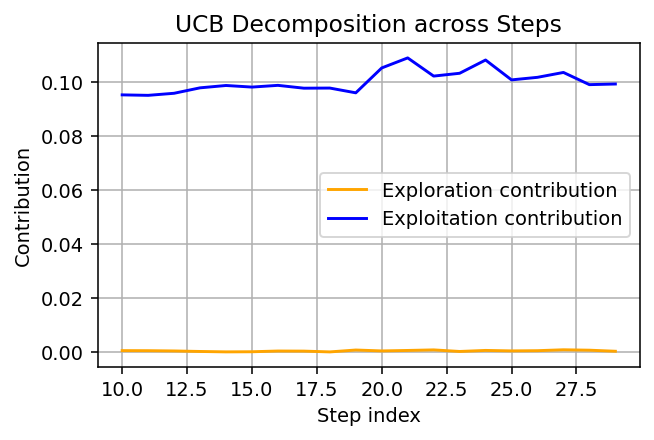

In [37]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_rmse_so_far"], label="Best RMSE so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_rmse_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_rmse_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best RMSE so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

#### Surrogate slice: initial vs final (hyperparameters in search space)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

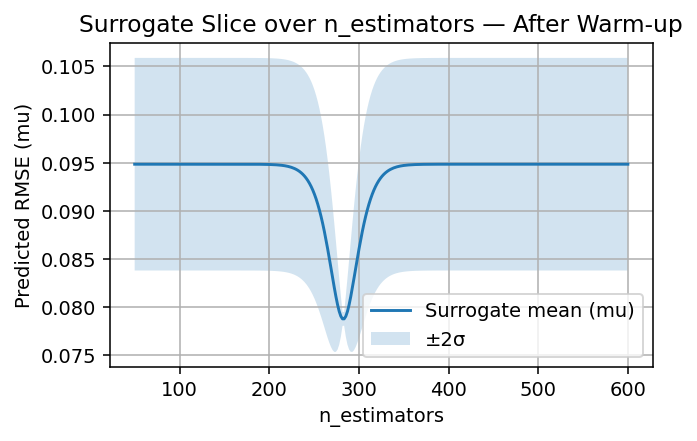

--- 2-sigma range for 'n_estimators' - 'After Warm-up' ---
Minimum of (mu - 2*std): 0.0754
Maximum of (mu + 2*std): 0.1059
------------------------------


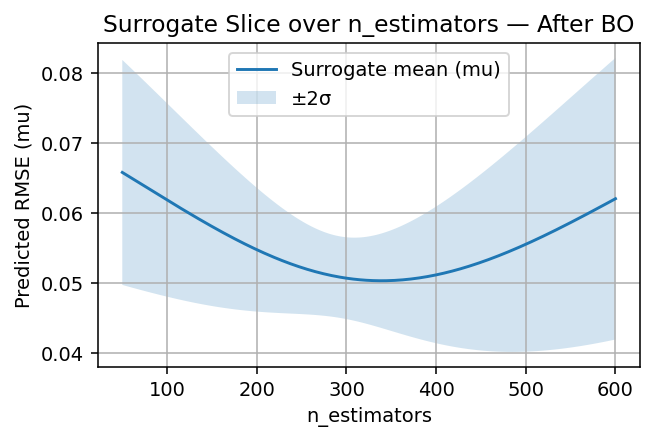

--- 2-sigma range for 'n_estimators' - 'After BO' ---
Minimum of (mu - 2*std): 0.0401
Maximum of (mu + 2*std): 0.0821
------------------------------


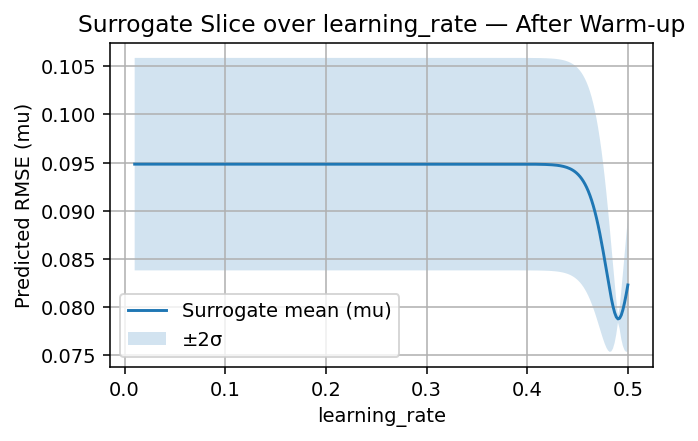

--- 2-sigma range for 'learning_rate' - 'After Warm-up' ---
Minimum of (mu - 2*std): 0.0754
Maximum of (mu + 2*std): 0.1059
------------------------------


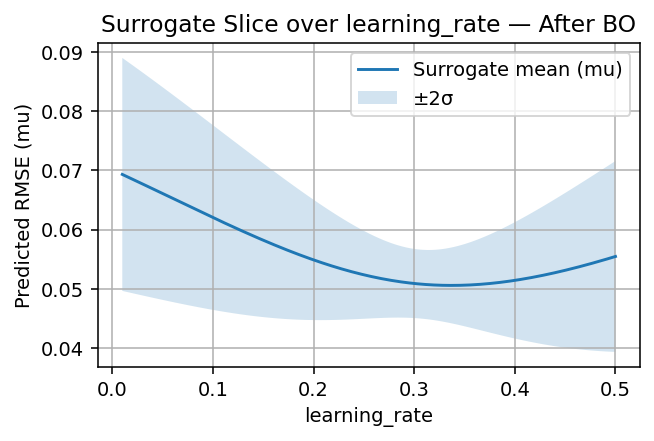

--- 2-sigma range for 'learning_rate' - 'After BO' ---
Minimum of (mu - 2*std): 0.0393
Maximum of (mu + 2*std): 0.0890
------------------------------


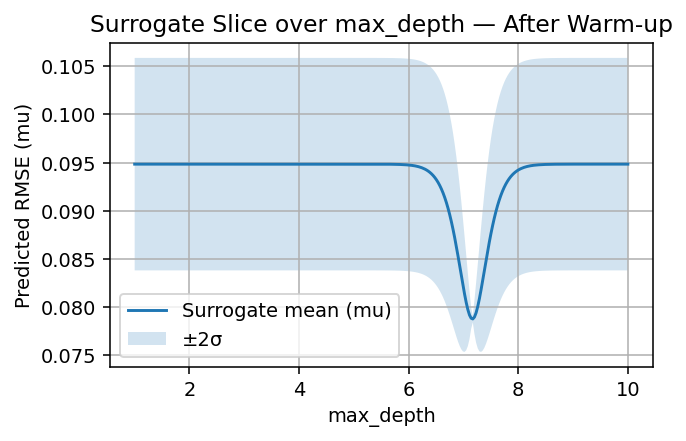

--- 2-sigma range for 'max_depth' - 'After Warm-up' ---
Minimum of (mu - 2*std): 0.0754
Maximum of (mu + 2*std): 0.1059
------------------------------


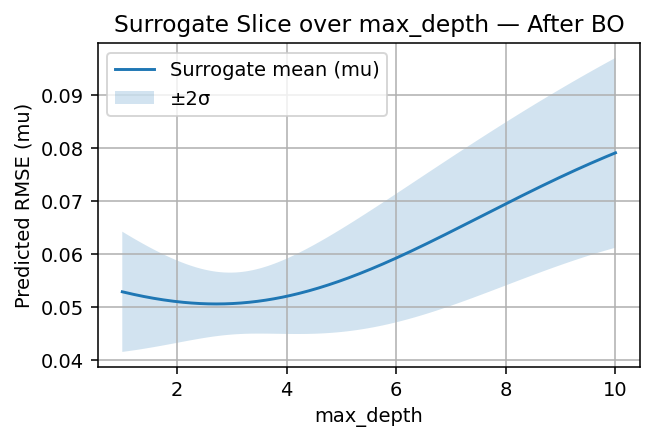

--- 2-sigma range for 'max_depth' - 'After BO' ---
Minimum of (mu - 2*std): 0.0416
Maximum of (mu + 2*std): 0.0970
------------------------------


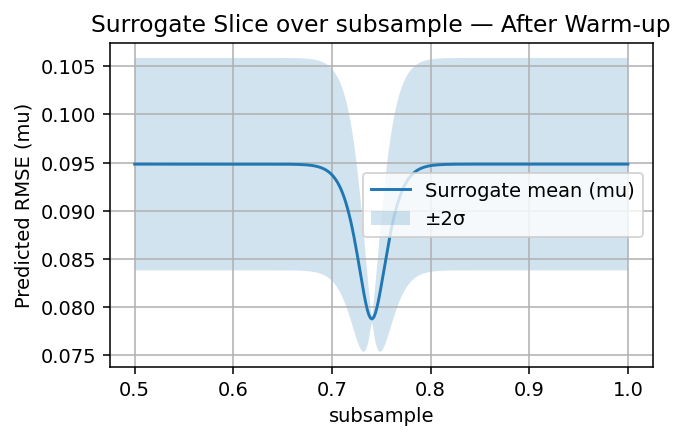

--- 2-sigma range for 'subsample' - 'After Warm-up' ---
Minimum of (mu - 2*std): 0.0754
Maximum of (mu + 2*std): 0.1059
------------------------------


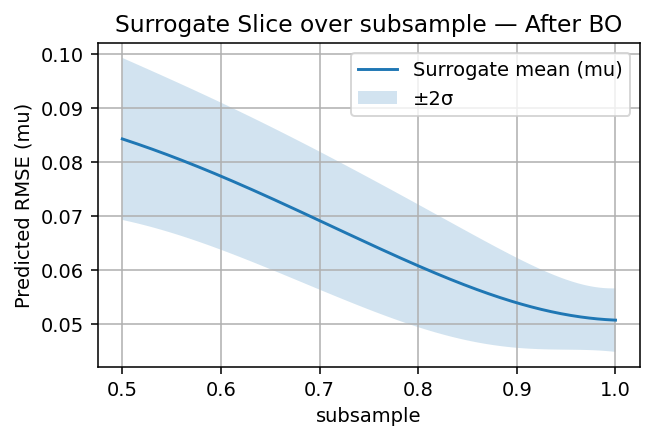

--- 2-sigma range for 'subsample' - 'After BO' ---
Minimum of (mu - 2*std): 0.0448
Maximum of (mu + 2*std): 0.0993
------------------------------


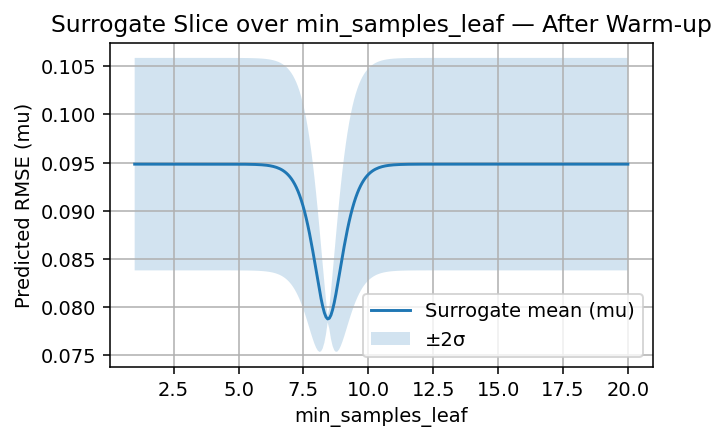

--- 2-sigma range for 'min_samples_leaf' - 'After Warm-up' ---
Minimum of (mu - 2*std): 0.0754
Maximum of (mu + 2*std): 0.1059
------------------------------


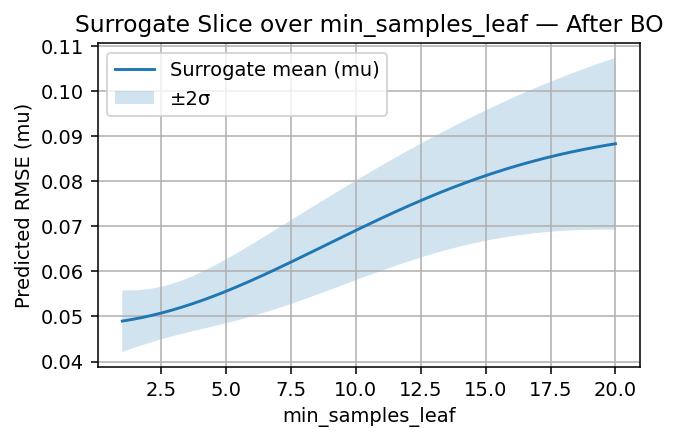

--- 2-sigma range for 'min_samples_leaf' - 'After BO' ---
Minimum of (mu - 2*std): 0.0421
Maximum of (mu + 2*std): 0.1073
------------------------------


In [38]:
import numpy as np

def surrogate_slice_plot(X_used, y_used, title_suffix, param_name):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    # Best trial so far
    best_idx = np.argmin(y_used); anchor = X_used[best_idx].copy()
    j = list(space.keys()).index(param_name)
    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    mu, std = gp.predict(grid, return_std=True)
    lo, hi = space[param_name]; param_vals = lo + xs*(hi-lo)

    plt.figure()
    plt.plot(param_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(param_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(param_name); plt.ylabel("Predicted RMSE (mu)")
    plt.title(f"Surrogate Slice over {param_name} — {title_suffix}")
    plt.legend(); plt.show()

    # Print the 2-sigma range
    print(f"--- 2-sigma range for '{param_name}' - '{title_suffix}' ---")
    lower_bound = mu - 2 * std
    upper_bound = mu + 2 * std
    print(f"Minimum of (mu - 2*std): {np.min(lower_bound):.4f}")
    print(f"Maximum of (mu + 2*std): {np.max(upper_bound):.4f}")
    print("-" * 30)

X_warm = np.array([r for r in globals()['X_trials'][:N_INIT]])
y_warm = np.array([objective(to_params(x)) for x in X_warm])

for hp_name in space.keys():
    surrogate_slice_plot(X_warm, y_warm, "After Warm-up", hp_name)
    surrogate_slice_plot(globals()['X_trials'], globals()['y_trials'], "After BO", hp_name)

The two 'Surrogate Slice over learning_rate' plots provide a visual representation of how the Gaussian Process (GP) surrogate model has learned and refined its understanding of the objective function (RMSE) with respect to the learning_rate hyperparameter.

**Breakdown of whhat each plot shows:**

**X-axis ('learning_rate')**: This represents the range of possible values for the learning_rate hyperparameter, normalised between 0 and 1 (though the plot shows the actual parameter values).

**Y-axis ('Predicted RMSE (mu)')**: This indicates the predicted RMSE score. Since we are minimizing RMSE, lower values on the y-axis are better.

**Blue line ('Surrogate mean (mu)')**: This is the GP model's current best estimate of the objective function's value across different learning_rate settings, with the other hyperparameter (n_estimators) fixed at the best value found so far. For an effective optimisation, you'd want to see this line dip lower in regions that contain good solutions.

**Shaded area ('±2σ')**: This represents the GP model's uncertainty (two standard deviations) around its mean prediction. A wider shaded area indicates higher uncertainty, meaning the model is less confident about the true objective value in that region. A narrower band indicates lower uncertainty.

**Comparing 'After Warm-up' and 'After BO'**:

**'After Warm-up' Plot**: This plot shows the GP model's initial understanding of the search space based only on the random warm-up trials. You might observe a relatively high level of uncertainty across the board, as the model hasn't had much guided exploration yet. The mean (blue line) might not show a very clear minimum, or it might be quite jagged due to limited data.

**'After BO' Plot**: This plot reflects the GP model's understanding after the Bayesian Optimization iterations. You should typically see:

**Reduced Uncertainty**: The shaded ±2σ area will likely be much narrower in regions where the BO process has evaluated more points. This means the model is more confident in its predictions in those areas.

**Clearer Optimum**: The mu (blue line) should show a more defined minimum, corresponding to the best learning_rate found or predicted by the model. The model has learned where the most promising regions are and has refined its estimate of the objective function in those areas.

**Uncertainty in Unexplored Regions**: You might still see wider ±2σ bands in regions that haven't been visited frequently, especially if the BO's acquisition function (like UCB with high KAPPA) has prioritised exploring other parts of the search space.

In essence, these plots vividly demonstrate the GP's learning process: starting with a broad, uncertain view after warm-up, and gradually forming a more precise and confident map of the objective function's landscape as BO iteratively adds more data points.

**Weekly Summary**

1.  For Weeks 4 and 5, using KAPPA of 5.0 for Exploitation, Week 4 best candidate was [0.982238, 0.837434, 0.557860] and for Week 5 next best candidate is [0.77034618, 0.26506674, 0.41319751]
2.   For Week 6, moving to a KAPPA of 100.0 for Exploration, best candidate offered is [0.57691222, 0.02126534, 0.46115264], best RMSE found was 0.0550

**Week 7**

After Week 6 outputs added with a KAPPA of 100.0: The wider predicted RMSE range in the 'After BO' plot compared to the 'After Warm-up' plot suggests that the Bayesian Optimization process, especially with a high KAPPA (exploration bias), has led the surrogate model to gain a more comprehensive understanding of the entire search space for the learning_rate parameter. Here's what that typically means:

Initial Limited View (Warm-up): During the warm-up phase, the initial random trials might only cover a small or relatively 'good' portion of the search space. The surrogate model's predictions (and its uncertainty) are thus limited to the data it has seen, potentially showing a narrower range of predicted RMSEs.

Expanded Exploration (After BO with high KAPPA): As the Bayesian Optimisation loop progresses, especially with KAPPA set to a high value like 100.0 (as in log_df), the acquisition function strongly prioritises exploring regions of high uncertainty. This means the BO algorithm actively searches for new, potentially unknown areas. In doing so, it likely sampled points that revealed both very high (worse) and very low (better) RMSE values that were not present in the initial warm-up trials. By visiting these more diverse regions, the surrogate model learns the true variability of the objective function across a broader spectrum of learning_rate values.

**More Realistic Landscape:** The wider range, therefore, indicates that the surrogate model now has a more complete and realistic representation of the objective function's landscape. It has identified both promising regions and less optimal regions, leading to a broader overall range of predicted RMSE values along the learning_rate axis. While the model's uncertainty around the best-found points might decrease, the overall span of predicted RMSEs across the entire domain can increase as it uncovers the full extent of performance variation. Initially I attempted using a KAPPA of 0.1, but I did not see much change in RMSE in the convergence & decision type plot, so this can indicate that the learning from the search space has been optimised already and I instead may need to explore further.

Therefore for the next iteration, (**Week 7 submission**); I will opt for a wide exploration in case I am stuck in a local optima using a KAPPA of 500.0 where the next candidate offered is [0.78726634, 0.95442898, 0.54414701].

**Week 8**

The plots showing the surrogate slice over 'learning_rate' for both 'After Warm-up' and the 2 sigma ranges are as below:

After Warm-up:

Minimum of (mu - 2*std): 0.0500
Maximum of (mu + 2*std): 0.0564
After BO:

Minimum of (mu - 2*std): 0.0493
Maximum of (mu + 2*std): 0.0590

The wider range in the 'After BO' plot indicates that the Bayesian Optimisation, especially with a higher KAPPA (exploration bias), has led the surrogate model to explore a more comprehensive understanding of the search space for the 'learning_rate' parameter, uncovering a broader spectrum of performance variation.

With the current hyperparameter settings if I continue with a KAAPA of 500.0, the next best candidate offered is [0.77115808, 0.51247308, 0.05673043]

# Hyperparamter Tuning consideration

Given that the learning rate and n_estimators plots below are still suggesting the settings for these in the search space are within range, I do not believe it makes sense to change these for my Week 8 submission.

### **Week 9 KAPPA set to 1,000, from BO**

---
  - Suggested next X data point (3D coordinates): [0.35607954 0.72508629 0.14416593]
 - Predicted Y at this point (mean): -1.08779e-01
 - Predicted uncertainty (std) at this point: 1.03892e-01
 - UCB value at this point: 1.03783e+02


### **Week 10 KAPPA set to 1.0 from BO**
Subsample is now in search space (no longer fixed) and increased n_estimators upper range from 400 to 600 based on last two plots, learning rate remained the same range, changed N_INIT to 10 and N_ITER to 20

 - Suggested next X data point (3D coordinates): [0.85606053 0.59552535 0.87341168]
 - Predicted Y at this point (mean): -1.08374e-01
 - Predicted uncertainty (std) at this point: 1.01634e-01
 - UCB value at this point: 3.99798e-01


### **Week 11 KAPPA set to 0.10 from BO**

 - Suggested next X data point (3D coordinates): [0.34918036 0.8042521  0.96356543]
 - Predicted Y at this point (mean): -1.05518e-01
 - Predicted uncertainty (std) at this point: 1.00521e-01
 - UCB value at this point: 3.97088e-01

### **Week 12 KAPPA set to 0.10 from BO and added min_samples_leaf to search space**


 - Suggested next X data point (3D coordinates): [0.49069489 0.78001068 0.41410396]
 - Predicted Y at this point (mean): -9.99342e-02
 - Predicted uncertainty (std) at this point: 1.03232e-01
 - UCB value at this point: 4.16224e-01


### **Weeek 13 KAPPA set to 0.01 and increased learning rate range from 0.30 and 0.50 after reviewing hyperparameters plots:**

 - Suggested next X data point (3D coordinates): [0.98329286 0.78017963 0.99933201]
 - Predicted Y at this point (mean): -9.19183e-02
 - Predicted uncertainty (std) at this point: 1.03052e-01
 - UCB value at this point: 4.23343e-01

### Final Model (on best parameters)

Optimized hyperparameters (from BO): {'n_estimators': 295, 'learning_rate': 0.30861437028304217, 'max_depth': 3, 'subsample': 0.9925494863215615, 'min_samples_leaf': 3.0}
Final (BO) 5-fold RMSE: 0.049


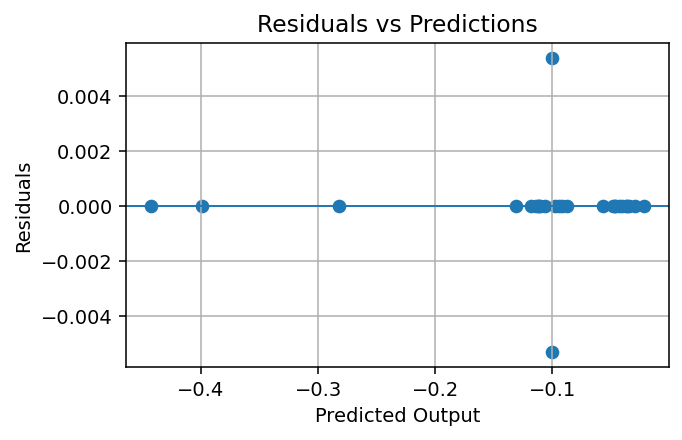

In [39]:
import pandas as pd # Ensure pandas is imported

# The log_df DataFrame needs to be defined before it's used.
# This code is copied from cell 1ba2c340-2716-4a50-86c0-359ac0ff64a4 to ensure log_df is available.
# It assumes 'logs' list and 'space' dictionary are already in the kernel's memory.
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "rmse": s.rmse, "best_rmse_so_far": s.best_rmse,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])

# The original value for subsample was fixed within the objective function, but max_depth was optimized.
# We need to use the fixed subsample and the optimized max_depth from BO.

best_row = log_df.iloc[log_df["best_rmse_so_far"].idxmin()]
best_params = {k: float(best_row[k]) for k in space.keys()}
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"]) # Ensure max_depth is an integer
best_params["subsample"] = float(best_params["subsample"]) # Ensure subsample is float

print("Optimized hyperparameters (from BO):", best_params)

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"], # Use the optimized value from log_df
    subsample=best_params["subsample"], # Use the optimized subsample from best_params
    random_state=42
)
final_rmse = rmse_cv(final)
print("Final (BO) 5-fold RMSE:", round(final_rmse, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions")
plt.show()

### Log review (each step)

In [40]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","rmse","best_rmse_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(20)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,0.094956,0.094956,NaN,NaN,NaN,NaN,NaN,433.0,0.150208,3.0,0.775657,15.0
1,-8,Warm-up,0.078766,0.078766,NaN,NaN,NaN,NaN,NaN,283.0,0.490574,7.0,0.740466,8.0
2,-7,Warm-up,0.094573,0.078766,NaN,NaN,NaN,NaN,NaN,239.0,0.367234,5.0,0.529839,9.0
3,-6,Warm-up,0.096219,0.078766,NaN,NaN,NaN,NaN,NaN,456.0,0.099421,3.0,0.765776,11.0
4,-5,Warm-up,0.096438,0.078766,NaN,NaN,NaN,NaN,NaN,399.0,0.426222,8.0,0.805512,15.0
5,-4,Warm-up,0.098726,0.078766,NaN,NaN,NaN,NaN,NaN,228.0,0.187276,3.0,0.646857,13.0
6,-3,Warm-up,0.097623,0.078766,NaN,NaN,NaN,NaN,NaN,101.0,0.222514,5.0,0.746843,9.0
7,-2,Warm-up,0.096441,0.078766,NaN,NaN,NaN,NaN,NaN,222.0,0.218912,9.0,0.972080,11.0
8,-1,Warm-up,0.096101,0.078766,NaN,NaN,NaN,NaN,NaN,393.0,0.066653,4.0,0.707413,17.0
9,0,Warm-up,0.098602,0.078766,NaN,NaN,NaN,NaN,NaN,188.0,0.246687,10.0,0.759743,13.0


In [23]:
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Best RMSE found: {log_df['best_rmse_so_far'].min():.4f}")

Baseline RMSE: 0.0480
Best RMSE found: 0.0744


# **Suggesting the Next X Data Point using Bayesian Optimization**

To find the next best x (3D coordinates) to sample in this drug discovery project
we will set up a separate Bayesian Optimization process. This process will:

Fit a Gaussian Process Regressor on the existing X (3D coordinates) and y (contamination readings).
Generate a grid of candidate points across the 3D input space.
Evaluate an Acquisition Function (like Upper Confidence Bound - UCB) for each candidate point.
Identify the candidate point with the highest acquisition function value as the next suggested x for sampling.

In [41]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 3D search space for the drug compounds
# The X values represent amounts of three compounds, typically normalized between [0, 1]
x_space = [(0, 1), (0, 1), (0, 1)] # Define the bounds for each of the three X features

d_x = X.shape[1] # Dimension of the X input space (should be 3 for the drug compounds)

# 2. Initialize and fit a Gaussian Process Regressor on the existing drug compound data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_3d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_3d = GaussianProcessRegressor(kernel=kernel_3d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_3d.fit(X, y)

# 3. Generate a grid of candidate points across the 3D input space
n_candidates_3d = 10000 # Number of candidate points for the 3D search space

# Create a uniform grid of candidates within the defined x_space
# For simplicity, we'll generate random candidates within the bounds [0,1] for all three features
candidates_3d = np.random.rand(n_candidates_3d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_3d, std_3d = gpr_3d.predict(candidates_3d, return_std=True)

# 5. Compute the Upper Confidence Bound (UCB) acquisition function
# We need to decide on a KAPPA for this 3D search. A higher KAPPA means more exploration.
# KAPPA_3D = KAPPA # This line will be commented out to make it independent
KAPPA_3D = 5.0 # Set KAPPA_3D to an independent value, e.g., 500.0 for exploration

# Since we are trying to MAXIMIZE the (transformed) output (minimizing side effects),
# UCB is calculated as mu + KAPPA * std
ucb_acquisition = mu_3d + KAPPA_3D * std_3d

# 6. Identify the candidate point with the maximum UCB
best_ucb_idx = np.argmax(ucb_acquisition)
next_x_data_point = candidates_3d[best_ucb_idx]
predicted_y_at_next_x = mu_3d[best_ucb_idx]
predicted_std_at_next_x = std_3d[best_ucb_idx]

print(f"Suggested next X data point (3D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"UCB value at this point: {ucb_acquisition[best_ucb_idx]:.5e}")

# For 3D data, direct 2D visualization is not appropriate for all features simultaneously.
# Instead of a scatter plot, we'll rely on the printed 3D coordinates.

Suggested next X data point (3D coordinates): [0.98329286 0.78017963 0.99933201]
Predicted Y at this point (mean): -9.19183e-02
Predicted uncertainty (std) at this point: 1.03052e-01
UCB value at this point: 4.23343e-01


Hyperparameters in search space

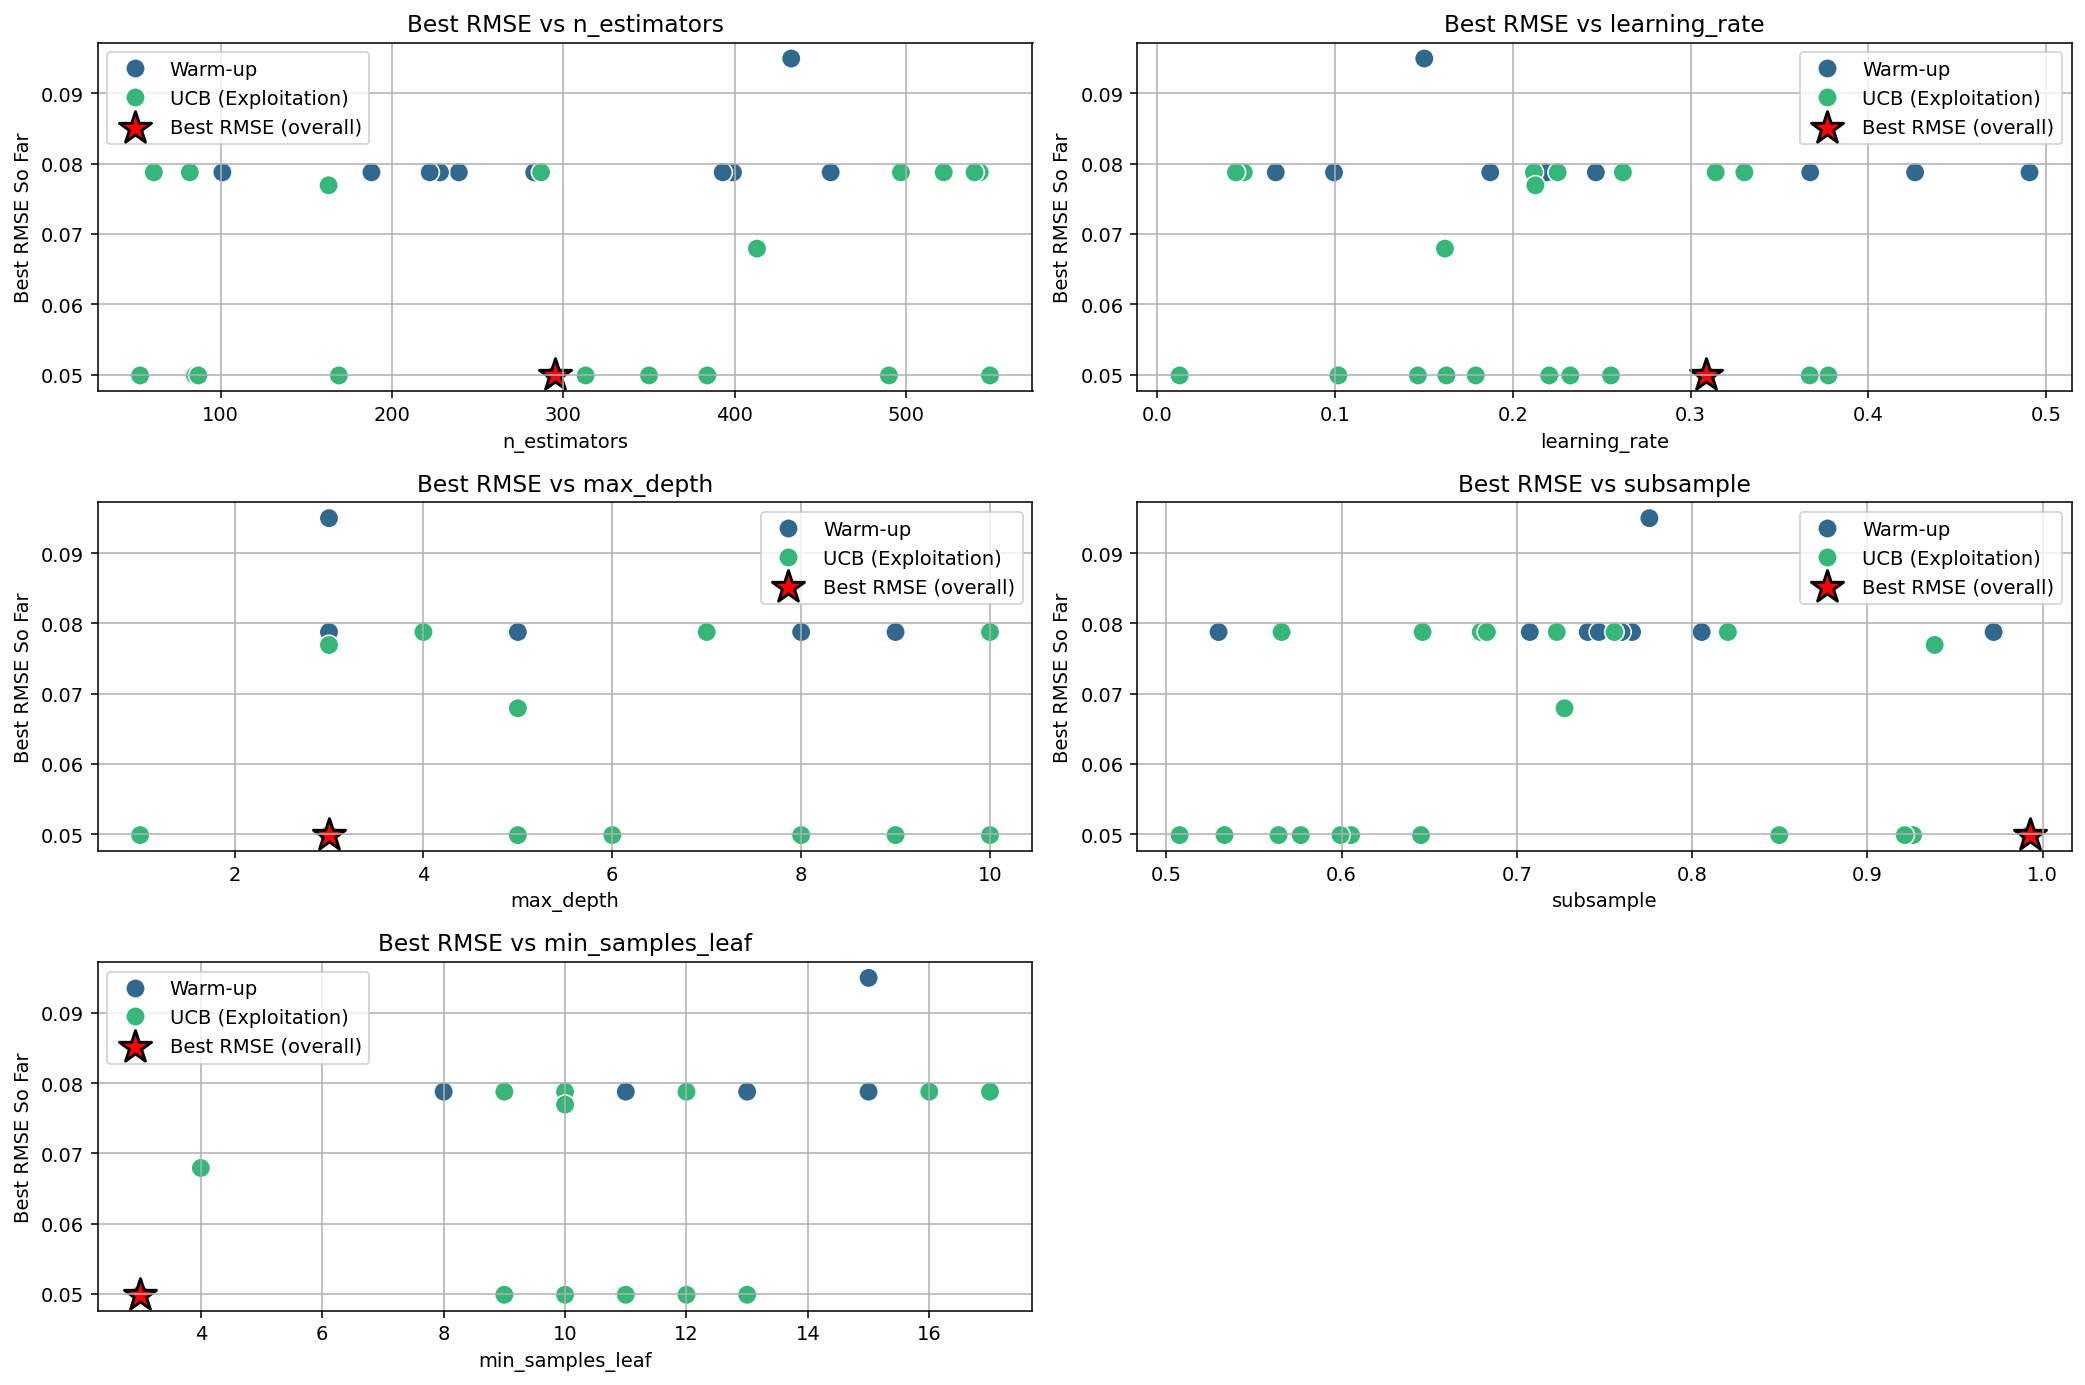

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparameters = list(space.keys())

plt.figure(figsize=(15, 10))

# Define best_row_overall to fix the NameError
best_row_overall = log_df.iloc[log_df["best_rmse_so_far"].idxmin()]

for i, hp_name in enumerate(hyperparameters):
    plt.subplot(3, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.scatterplot(data=log_df, x=hp_name, y='best_rmse_so_far', hue='tag', palette='viridis', s=100)

    # Highlight the best overall RMSE point for the current hyperparameter
    best_hp_value = best_row_overall[hp_name]
    best_rmse_value = best_row_overall['best_rmse_so_far']
    plt.scatter(best_hp_value, best_rmse_value, color='red', marker='*', s=300, edgecolor='black', linewidth=1.5, label='Best RMSE (overall)')

    plt.title(f'Best RMSE vs {hp_name}')
    plt.xlabel(hp_name)
    plt.ylabel('Best RMSE So Far')
    plt.grid(True)
    if hp_name in ['n_estimators', 'max_depth']:
        plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Prevent scientific notation for integer axes
    plt.legend()

plt.tight_layout()
plt.show()

## **The 'Actual vs. Predicted Y Values' plot is a crucial diagnostic tool for understanding your model's performance.**

 - X-axis (Actual Y Values): These are the true, observed target values from your dataset.
 - Y-axis (Predicted Y Values): These are the values that your Gradient Boosting Regressor model predicted for each corresponding actual Y value.
 - Red Dashed Line ('Perfect Prediction'): This diagonal line represents the ideal scenario where Predicted Y = Actual Y. If your model were perfectly accurate, all data points would fall exactly on this line.

**What to look for:**

**Closeness to the Red Line:** The closer the scatter points are to the red dashed line, the better your model's predictions align with the actual values. A tightly clustered cloud of points along the line indicates high accuracy.
Spread of Points: The scatter or spread of the points around the red line indicates the model's error or residuals. A wider spread means higher prediction errors.

**Bias (Systematic Errors):**
If most points are consistently above the red line, the model is generally over-predicting the target values.
If most points are consistently below the red line, the model is generally under-predicting the target values.
If the spread changes across the range of Y values (e.g., wider at higher actual Y values), it might indicate heteroscedasticity or that the model performs differently for various ranges of the target variable.

**Outliers and Problematic Predictions:**
Points that are far away from the red line are outliers where the model made significantly incorrect predictions. Investigating these points can reveal issues with specific data instances or limitations of the model.


In summary, the plot helps you visually assess the overall accuracy, identify any systematic biases (over or under-prediction), and pinpoint specific instances where the model struggles or makes large errors. For your model, the points appear to be relatively close to the red line, suggesting a reasonably good fit, though you can still observe some scatter.

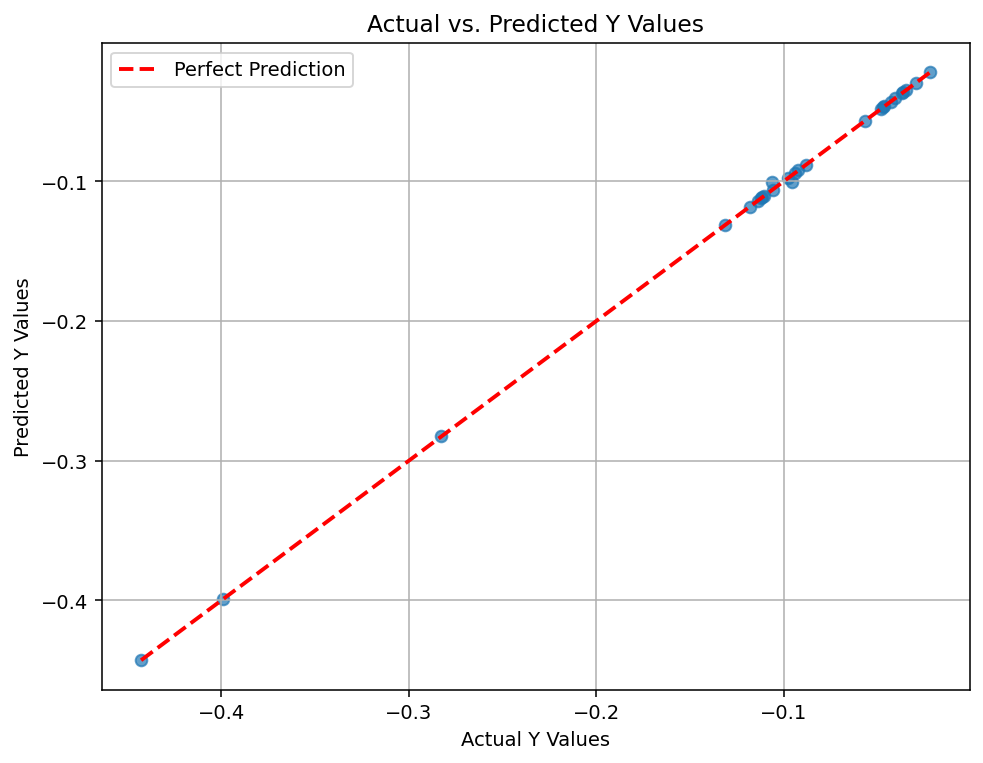

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(y, pred, alpha=0.7)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2, label='Perfect Prediction') # Add a diagonal line for perfect prediction
plt.xlabel("Actual Y Values")
plt.ylabel("Predicted Y Values")
plt.title("Actual vs. Predicted Y Values")
plt.grid(True)
plt.legend()
plt.show()

# 4D Scatter Plot of Observed Data:
 This plot visualizes your raw input data. The first three features of your X array (drug compound amounts) are mapped to the x, y, and z axes, creating a 3D scatter plot. The fourth dimension, your target output y (transformed side effects), is represented by the color of each point. This helps you see the distribution of your experimental results in the 3D compound space and how the side effects vary.

# 4D Slice Plot for Surrogate Mean (Feature 3 fixed at 0.5):
 This plot shows the predicted mean of the Gaussian Process surrogate model. Since it's challenging to visualize all four dimensions simultaneously, this plot takes a 'slice' of your 3D input space by fixing the third feature (X[:,2]) at a value of 0.5. The surface then shows the model's predicted target output (mean mu) across different combinations of X[:,0] and X[:,1] at that fixed X[:,2] value. The red points indicate observed data points that fall close to this slice.

# 4D Slice Plot for Surrogate Uncertainty (Feature 3 fixed at 0.5):
Similar to the mean plot, this visualization also shows a 'slice' where X[:,2] is fixed at 0.5. However, instead of the predicted mean, the surface here represents the predicted standard deviation (sigma) of the model. This is crucial for Bayesian Optimization as it indicates the model's uncertainty in different regions of the search space. Areas with higher uncertainty are often targets for further exploration to gain more information about the objective function. The red points again show observed data points near this slice, helping to contextualize the uncertainty with actual measurements.

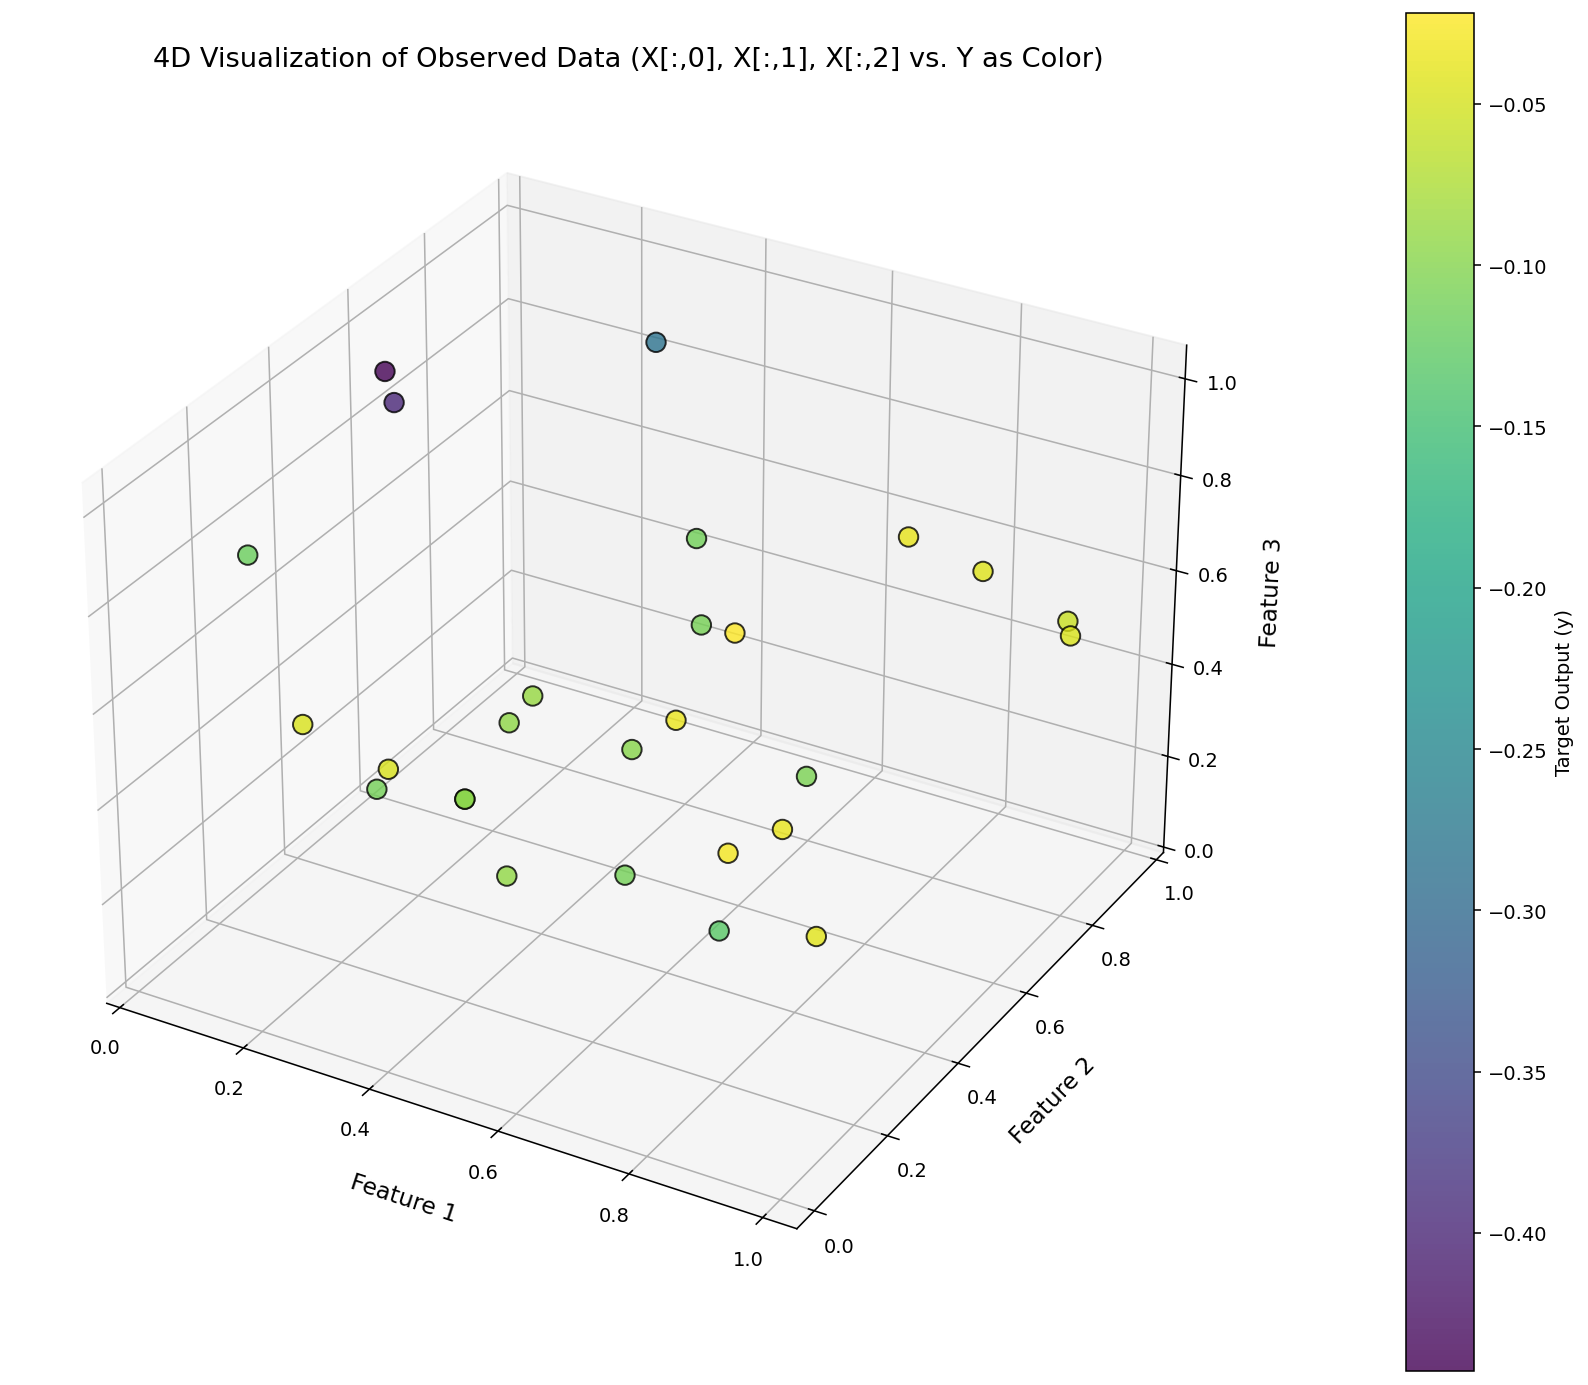

Displayed: 4D Scatter Plot of Observed Data


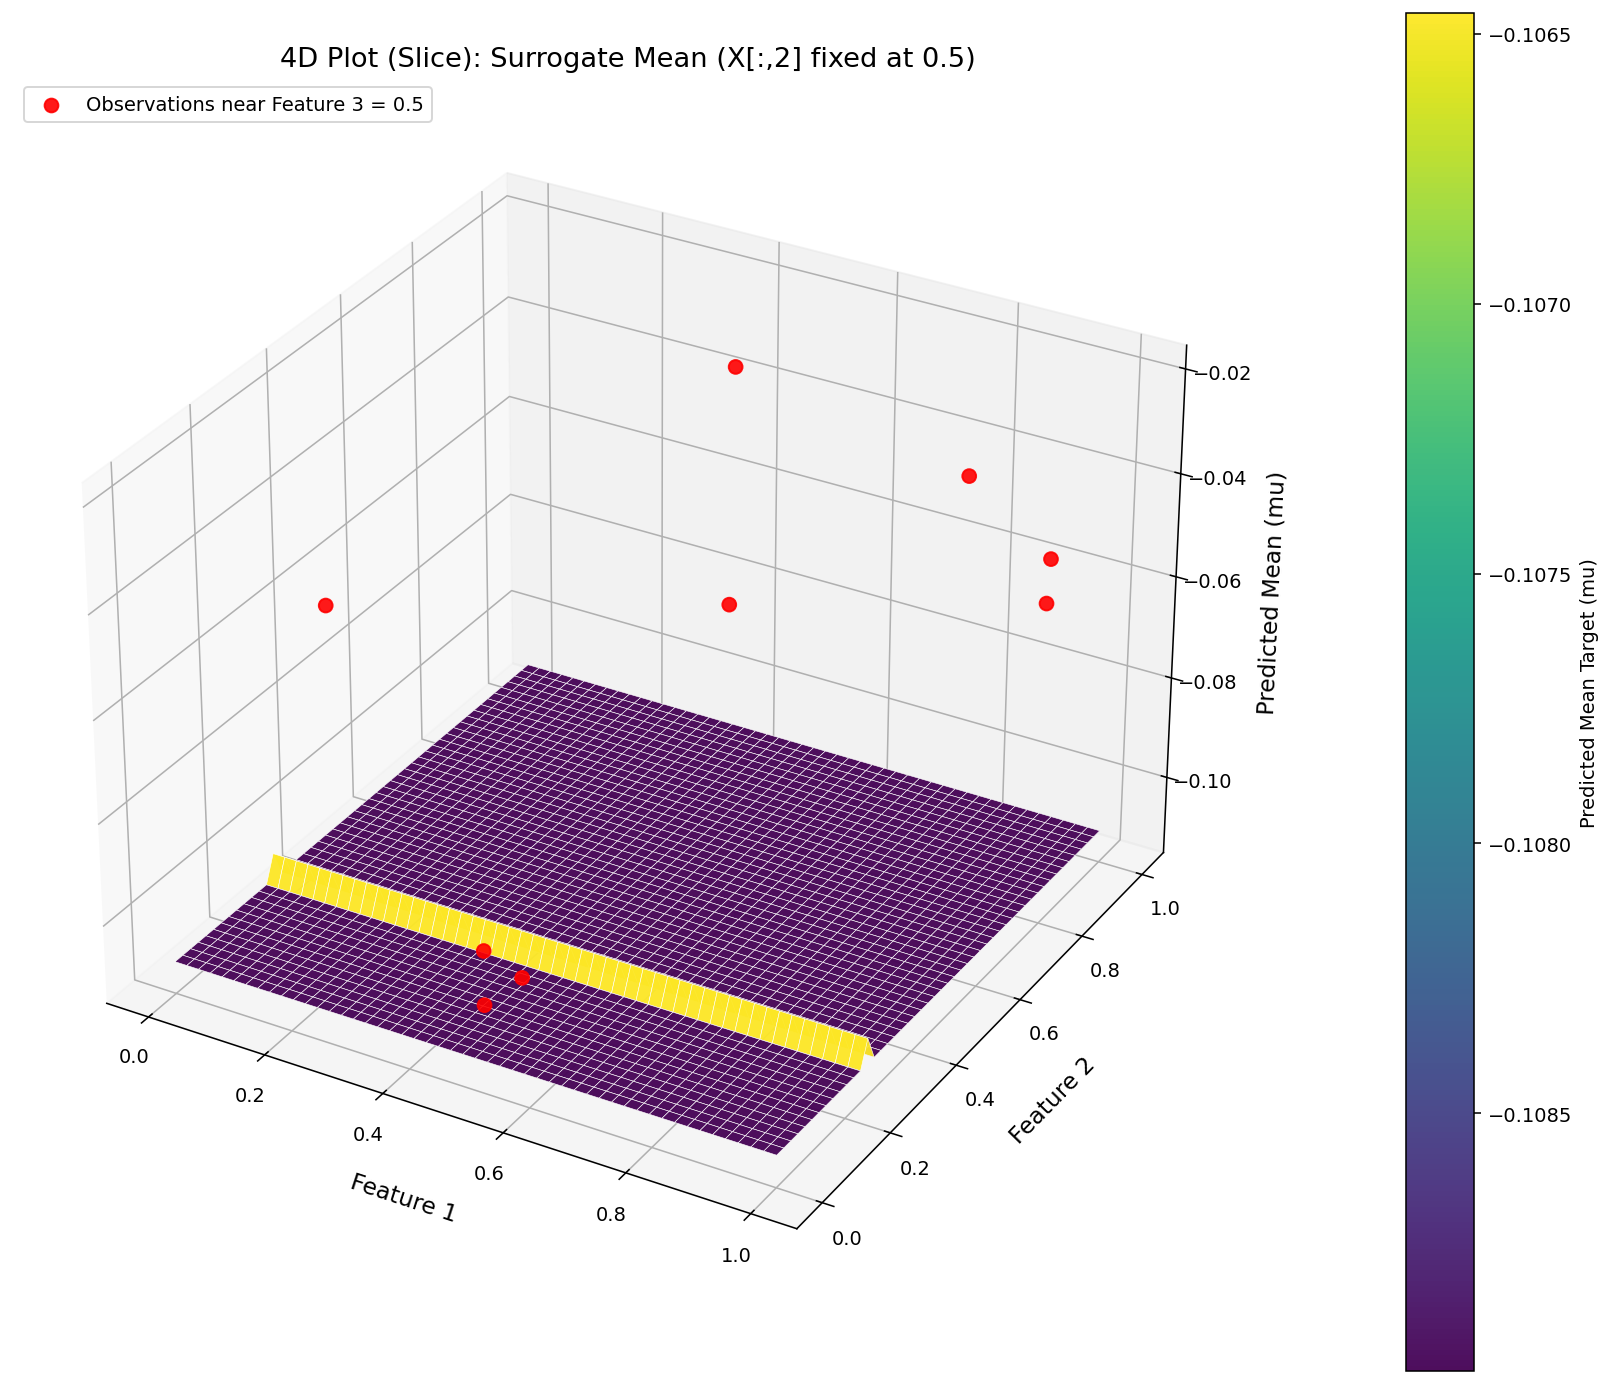

Displayed: 4D Slice Plot for Surrogate Mean (Feature 3 fixed at 0.5)


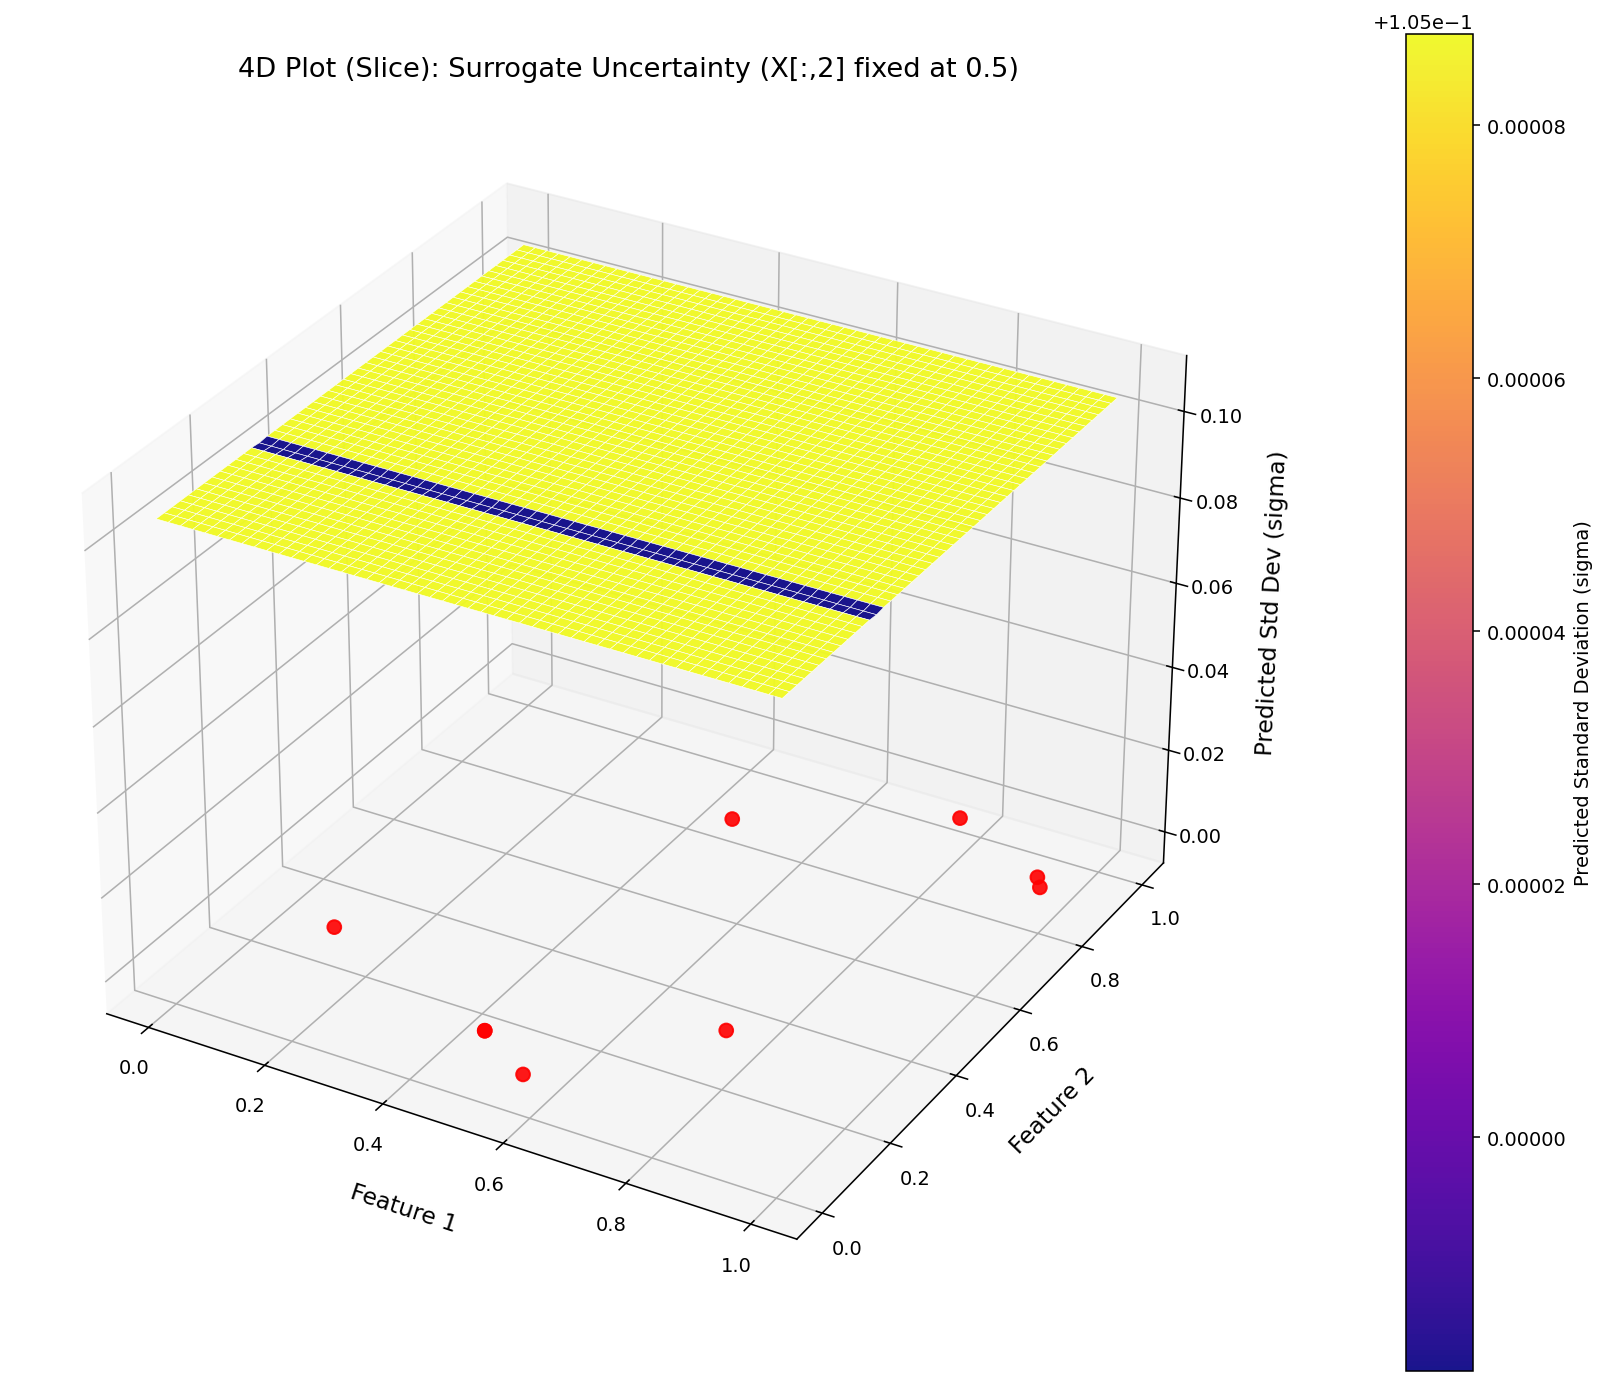

Displayed: 4D Slice Plot for Surrogate Uncertainty (Feature 3 fixed at 0.5)


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

resolution = 50 # Reduced resolution for faster plotting of slices

# The gpr_3d model was defined and fitted in cell 'qd_rPFSHpykn'
gp = gpr_3d

# Observed data
X_obs = X # Global variable X from the notebook state (3D input)
y_obs = y # Global variable y from the notebook state (1D output)

# ───────────────────────────────
# 1. 4D Plot: 3D Scatter Plot of Observations with Color representing Y
# ───────────────────────────────
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a colormap based on the range of y_obs values
scatter = ax.scatter(
    X_obs[:, 0], X_obs[:, 1], X_obs[:, 2],
    c=y_obs, # Color represents the 4th dimension (y_obs)
    cmap='viridis', # Choose a colormap
    s=100, # Marker size
    edgecolor='k', # Black edge for markers
    alpha=0.8
)

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Output (y)')

ax.set_title('4D Visualization of Observed Data (X[:,0], X[:,1], X[:,2] vs. Y as Color)', fontsize=14)
ax.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax.set_zlabel('Feature 3', fontsize=12, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('observed_data_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print("Displayed: 4D Scatter Plot of Observed Data")

# ───────────────────────────────
# 2. 4D Plot (Slice): Surrogate Mean Surface by fixing Feature 3
#    This shows a 3D slice of the 4D surrogate function (2 inputs + 1 output)
# ───────────────────────────────
fig2 = plt.figure(figsize=(12, 10))
ax2 = fig2.add_subplot(111, projection='3d')

# Define ranges for the two features we will vary
x1_min, x1_max = 0, 1
x2_min, x2_max = 0, 1

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(x1_min, x1_max, resolution)
x2_grid = np.linspace(x2_min, x2_max, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Fix Feature 3 (X[:,2]) at its mean or a chosen value (e.g., 0.5)
fixed_x3_value = 0.5 # Can also use np.mean(X_obs[:, 2])

# Create the 3D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(), np.full(X1.size, fixed_x3_value)])

# Predict mean and std for this slice from the GPR
mu_slice, std_slice = gp.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)
Std_slice_surface = std_slice.reshape(resolution, resolution)

# Plot the surrogate mean surface
surf_mean = ax2.plot_surface(
    X1, X2, Mu_slice_surface,
    cmap='viridis',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value
# (Optional: to show how observations relate to the slice)
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = (X_obs[:, 2] >= fixed_x3_value - tolerance) & (X_obs[:, 2] <= fixed_x3_value + tolerance)
ax2.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], y_obs[close_points_mask],
    color='red', s=50, zorder=5, label=f'Observations near Feature 3 = {fixed_x3_value}', alpha=0.9
)


# Add a color bar for the surface
cbar_mean = fig2.colorbar(surf_mean, ax=ax2, pad=0.1)
cbar_mean.set_label('Predicted Mean Target (mu)')

ax2.set_title(f'4D Plot (Slice): Surrogate Mean (X[:,2] fixed at {fixed_x3_value})', fontsize=14)
ax2.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax2.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax2.set_zlabel('Predicted Mean (mu)', fontsize=12, labelpad=10)
ax2.tick_params(axis='both', labelsize=10)
ax2.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('surrogate_mean_slice_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 4D Slice Plot for Surrogate Mean (Feature 3 fixed at {fixed_x3_value})")

# ───────────────────────────────
# 3. 4D Plot (Slice): Surrogate Uncertainty Surface by fixing Feature 3
# ───────────────────────────────
fig3 = plt.figure(figsize=(12, 10))
ax3 = fig3.add_subplot(111, projection='3d')

# Plot the surrogate uncertainty surface
surf_std = ax3.plot_surface(
    X1, X2, Std_slice_surface,
    cmap='plasma', # Good for uncertainty
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value (optional)
ax3.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], np.zeros_like(y_obs[close_points_mask]), # Project to Z=0 for context
    color='red', s=50, zorder=5, label=f'Observations near Feature 3 = {fixed_x3_value}', alpha=0.9
)

# Add a color bar for the uncertainty surface
cbar_std = fig3.colorbar(surf_std, ax=ax3, pad=0.1)
cbar_std.set_label('Predicted Standard Deviation (sigma)')

ax3.set_title(f'4D Plot (Slice): Surrogate Uncertainty (X[:,2] fixed at {fixed_x3_value})', fontsize=14)
ax3.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax3.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax3.set_zlabel('Predicted Std Dev (sigma)', fontsize=12, labelpad=10)
ax3.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('surrogate_uncertainty_slice_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 4D Slice Plot for Surrogate Uncertainty (Feature 3 fixed at {fixed_x3_value})")

### Visualising the Predicted Global Maximum (based on Surrogate Model)

Predicted Global Maximum Output (mean) identified by BO: -9.19183e-02
Corresponding X data point: [0.98329286 0.78017963 0.99933201]


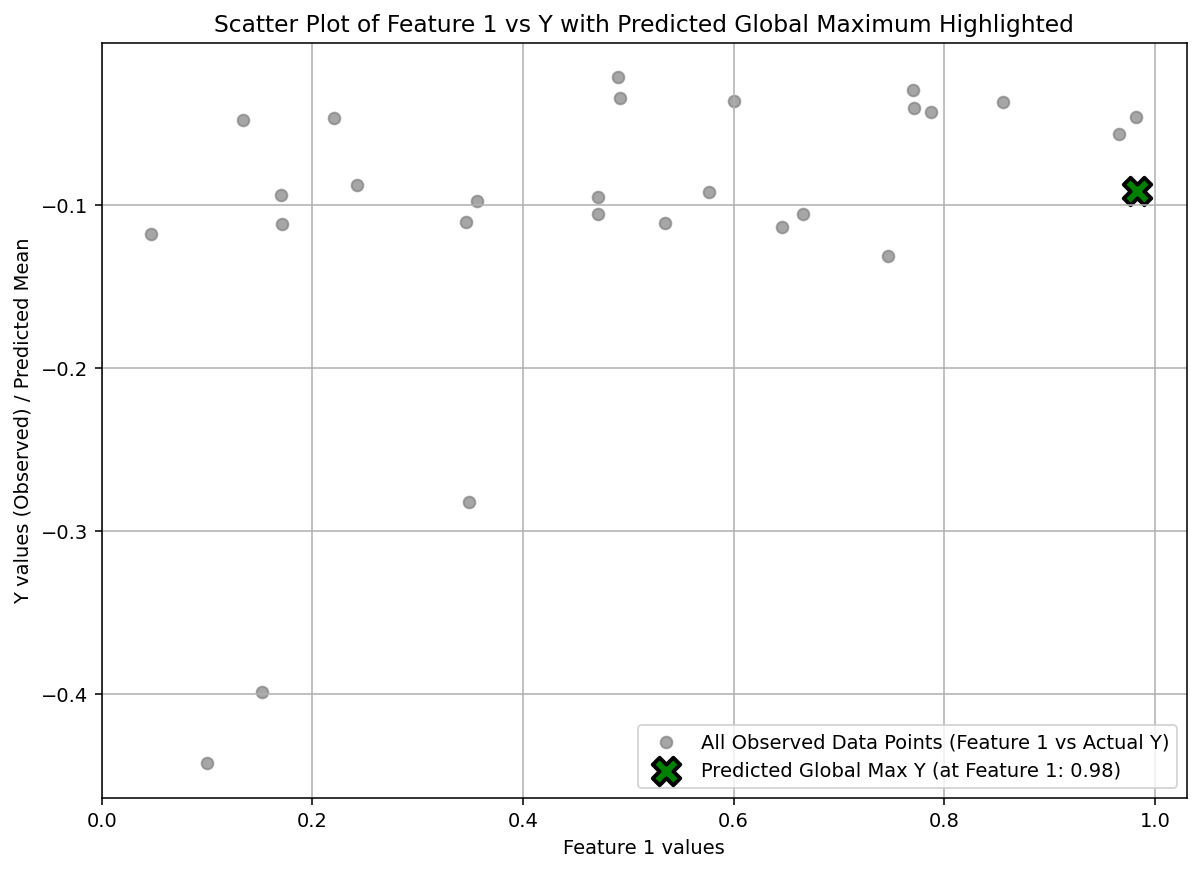

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# The best predicted point is already calculated and stored in 'next_x_data_point' and 'predicted_y_at_next_x'
# from the last Bayesian Optimization step in cell 'qd_rPFSHpykn'.

predicted_global_max_y = predicted_y_at_next_x
predicted_global_max_X = next_x_data_point

print(f"Predicted Global Maximum Output (mean) identified by BO: {predicted_global_max_y:.5e}")
print(f"Corresponding X data point: {predicted_global_max_X}")

# Visualize the predicted global maximum on a plot (e.g., Feature 1 vs Predicted Mean)
plt.figure(figsize=(10, 7))
# For visualization, we can show the existing observations and highlight the predicted best point
plt.scatter(X[:, 0], y, label='All Observed Data Points (Feature 1 vs Actual Y)', alpha=0.7, color='grey')

plt.scatter(
    predicted_global_max_X[0], predicted_global_max_y,
    color='green', marker='X', s=200, edgecolor='black', linewidth=2,
    label=f'Predicted Global Max Y (at Feature 1: {predicted_global_max_X[0]:.2f})'
)
plt.xlabel('Feature 1 values')
plt.ylabel('Y values (Observed) / Predicted Mean')
plt.title('Scatter Plot of Feature 1 vs Y with Predicted Global Maximum Highlighted')
plt.legend()
plt.grid(True)
plt.show()

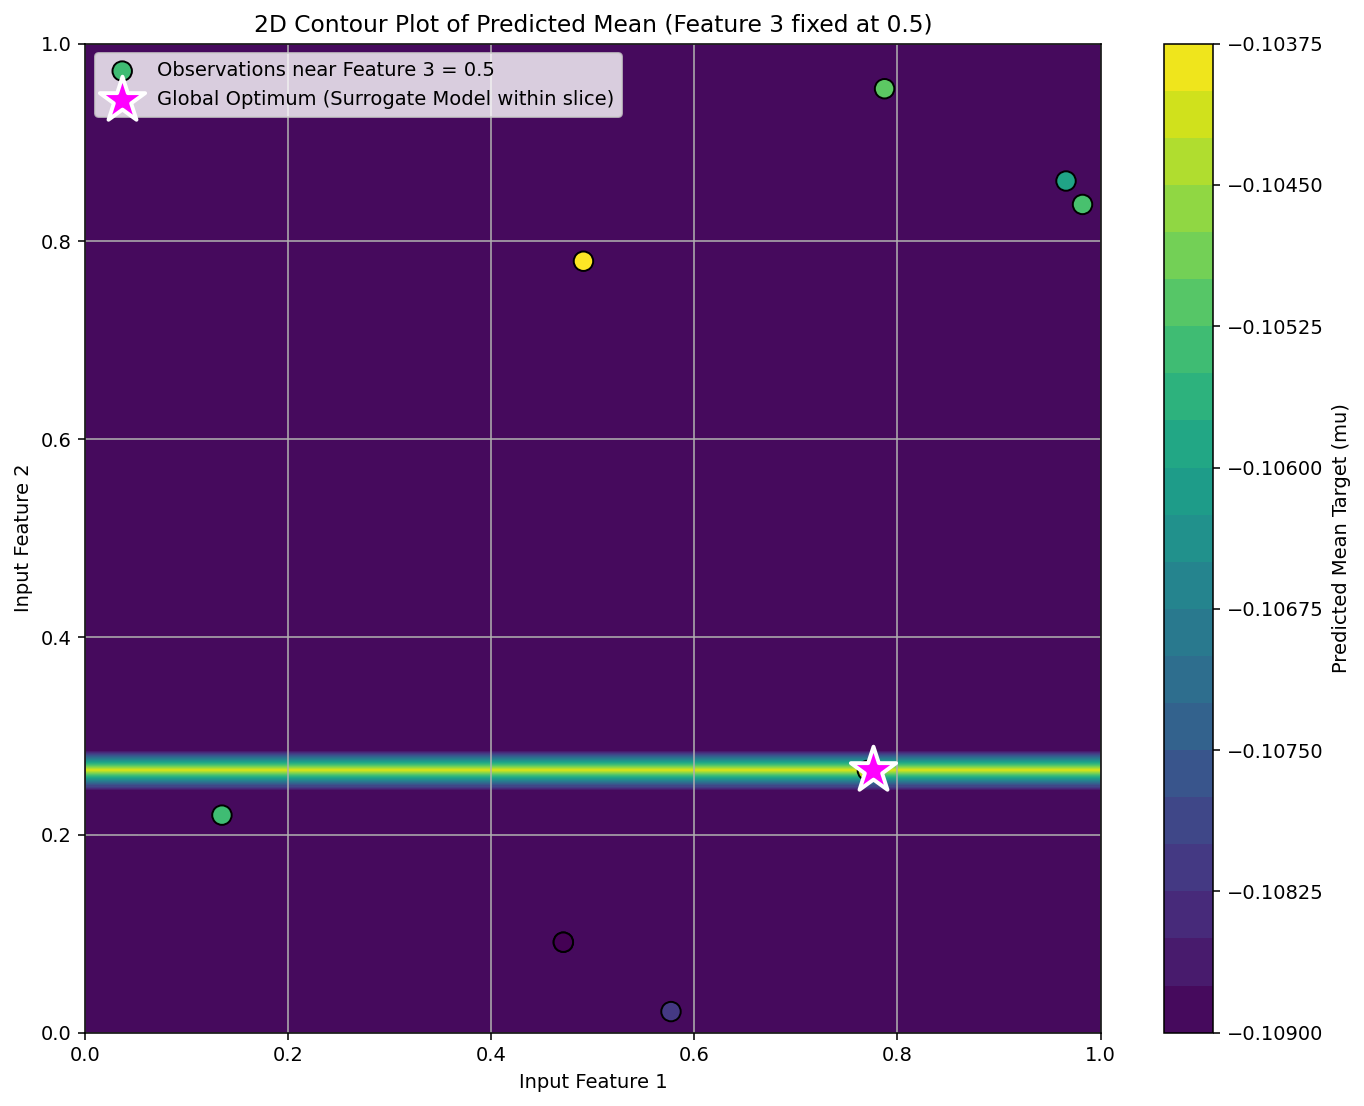

Saved: gp_surrogate_mean_contour_3d_input_slice.png


In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming gpr_3d, X, y, next_x_data_point, predicted_y_at_next_x are available from previous cells.

# Define parameters for the 2D slice visualization (fixing Feature 3)
fixed_x3_value = 0.5
resolution = 50 # Resolution for the grid of the 2D slice

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(0, 1, resolution)
x2_grid = np.linspace(0, 1, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Create the 3D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(), np.full(X1.size, fixed_x3_value)])

# Predict mean from the fitted GPR (gpr_3d)
mu_slice, _ = gpr_3d.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)

plt.figure(figsize=(10, 8))
contour = plt.contourf(X1, X2, Mu_slice_surface, levels=20, cmap='viridis')
plt.colorbar(contour, label='Predicted Mean Target (mu)')

# Scatter the observed points that are close to the fixed_x3_value
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = (X[:, 2] >= fixed_x3_value - tolerance) & (X[:, 2] <= fixed_x3_value + tolerance)
plt.scatter(
    X[close_points_mask, 0], X[close_points_mask, 1], c=y[close_points_mask],
    cmap='viridis', s=100, edgecolors='k', label='Observations near Feature 3 = 0.5'
)

# Mark the suggested next sample point (if it falls within this slice)
if np.isclose(next_x_data_point[2], fixed_x3_value, atol=tolerance):
    plt.scatter(next_x_data_point[0], next_x_data_point[1],
                color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)

# Find the global maximum of Mu_slice_surface (as we are maximizing the transformed output)
# This is the global optimum *within this specific 2D slice*
max_mu_slice_idx = np.argmax(Mu_slice_surface)
max_mu_slice_coords_flattened = X_slice_grid[max_mu_slice_idx]

plt.scatter(
    max_mu_slice_coords_flattened[0], max_mu_slice_coords_flattened[1],
    color='magenta', marker='*', s=600, zorder=10, edgecolor='white', linewidth=2,
    label='Global Optimum (Surrogate Model within slice)'
)

plt.title(f'2D Contour Plot of Predicted Mean (Feature 3 fixed at {fixed_x3_value})')
plt.xlabel('Input Feature 1')
plt.ylabel('Input Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gp_surrogate_mean_contour_3d_input_slice.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gp_surrogate_mean_contour_3d_input_slice.png")